# AVIRIS-NG CH₄ Hyperspectral Analysis — Physics, Mathematics, Fourier & Machine Learning


$$
\boxed{\text{Physics} \rightarrow \text{Signal Processing} \rightarrow \text{Retrieval} \rightarrow \text{Machine Learning}}
$$

The pipeline uses real AVIRIS-NG radiance data and a CH₄ retrieval/reference product. It explicitly distinguishes retrieval-derived pseudo-labels from independent ground truth.

Data source NASA Jet Propulsion Laboratory (JPL)

https://popo.jpl.nasa.gov/avng/AVNG_Benchmark_Methane_Carbon_Dioxide_Data/?utm_source=chatgpt.com


```text
RAW RADIANCE (rdn_memmap)
     │
     ├── wavelength validation (Sec.04)
     │
     └── CH4 spectral window (Sec.05)
                 │
                 ├── shoulder-band continuum removal (Sec.07)
                 │        │
                 │        ├── log-radiance ──────── PCA (diagnostic, Sec.10)
                 │        ├── continuum ratio ────── PCA (diagnostic, Sec.10)
                 │        │
                 │        └── log-radiance ─────┐
                 │                               │
UA TARGET (separate file) ──── interp (Sec.11) ──┴──> MATCHED FILTER
                                                        (own calc, Sec.12)
                                                        — baseline, independent
                 │
                 └── continuum removal ── ML features (X)  (Sec.14)


CH4 REFERENCE PRODUCT (separate file, JPL matched-filter band, Sec.13)
     │
     ├── ref map (used for physical interpretation, Sec.22)
     │
     └── y = reference values sampled at same pixels as X  (Sec.14)
                 │
                 ├── pseudo-label threshold from y, FULL SET ⚠
                 │   (not train-only — leakage, see note)
                 │
                 └── y_class, y_reg


         X, y_class, y_reg
                 │
                 ├── spatial split (train/test, buffered, Sec.15)
                 │
                 ├── RF classifier (Sec.17-18)
                 │        └── threshold calibrated on TRAIN only (Sec.18b) — OK
                 │
                 └── RF regressor (Sec.19-20)
                           │
                           └── SAME preprocessing, full scene (Sec.21)
                                  ↓
                           FULL-SCENE MAPS (pred_prob, pred_ch4)
                                  ↓
                   compared against CH4 reference product (Sec.22b)
                   [correlation, agreement, recall-on-positive, MAE/RMSE/R²]
                                  ↓
                   summarized in metrics table (Sec.24)
```

## 01. Project objective - プロジェクトの目的

We want to map methane (CH₄) from AVIRIS-NG hyperspectral radiance while retaining a clear physical interpretation of the retrieval.

For pixel $(r,c)$ the spectrum is:

$$
\mathbf{x}_{r,c}=[R(\lambda_1),...,R(\lambda_B)].
$$

The project produces spectral diagnostics, a CH₄ reference map, a classifier, a regressor, full-scene prediction maps and reproducible artifacts.

このプロジェクトでは、航空機搭載型ハイパースペクトルセンサー AVIRIS-NG によって取得されたデータを用いて、メタン（CH₄）のスペクトル特性を解析し、機械学習による検出・推定を行います。

In [1]:
# Imports and global configuration
import json, warnings
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from spectral import open_image
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score, roc_curve
)


utilitar central de validare

In [2]:
# --- Validation utility: collects pass/fail checks throughout the notebook ---
validation_log = []

def check(name, condition, detail=""):
    status = "PASS" if bool(condition) else "FAIL"
    validation_log.append({"check": name, "status": status, "detail": detail})
    symbol = "✓" if status == "PASS" else "✗"
    print(f"[{symbol}] {name}" + (f" — {detail}" if detail else ""))
    if status == "FAIL":
        warnings.warn(f"Validation failed: {name} ({detail})")
    return status == "PASS"

def validation_summary():
    df = pd.DataFrame(validation_log)
    n_fail = (df["status"] == "FAIL").sum()
    print(f"\n{'='*50}\nValidation summary: {len(df)-n_fail}/{len(df)} passed")
    if n_fail > 0:
        print("FAILED checks:")
        display(df[df["status"] == "FAIL"])
    return df

## 02. Dataset and AVIRIS-NG instrument - データセットとAVIRIS-NGセンサー

AVIRIS-NG provides hundreds of contiguous spectral channels. The methane-sensitive short-wave infrared region is around 2.3 µm.

The supplied scene is expected to contain approximately 3987 lines × 598 samples × 425 bands, with wavelengths spanning roughly 376–2500 nm.

通常のRGBカメラでは、1つのピクセルについて主に3つの値を取得します。
一方、ハイパースペクトルセンサーでは、1つのピクセルについて数百の異なる波長における信号を取得します。

In [3]:
# Paths
BASE_DIR = Path(".")
# Data files with radiance
RDN_HDR = BASE_DIR / "ang20160211t075004_rdn_v2m2_clip" / "ang20160211t075004_rdn_v2m2_clip.hdr"
# Data files with CH4 absorption
CH4_HDR = BASE_DIR / "ang20160211t075004_ch4" / "ang20160211t075004_ch4.hdr"
# Data file with CH4 unit absorption reference spectrum
UA_FILE = BASE_DIR / "ang20160211t075004_ch4" / "ang20160211t075004_ch4_ua.txt"

OUTPUT_DIR = BASE_DIR / "outputs"
MODEL_DIR = BASE_DIR / "models"
FIG_DIR = OUTPUT_DIR / "figures"
for d in (OUTPUT_DIR, MODEL_DIR, FIG_DIR): d.mkdir(parents=True, exist_ok=True)

assert RDN_HDR.exists(), f"Missing {RDN_HDR}"
assert CH4_HDR.exists(), f"Missing {CH4_HDR}"
assert UA_FILE.exists(), f"Missing {UA_FILE}"
print("Required headers found.")

Required headers found.


In [4]:
# Open the ~4 GB radiance cube using memory mapping
rdn_img = open_image(RDN_HDR)
rdn_memmap = getattr(rdn_img, "open_memmap")()
wavelengths = np.asarray(rdn_img.bands.centers, dtype=np.float32)
cube_shape = tuple(rdn_memmap.shape)

check(
    "Radiance cube shape",
    rdn_memmap.shape == cube_shape,
    f"memmap={rdn_memmap.shape}, header={cube_shape}"
)

check(
    "Wavelength count",
    len(wavelengths) == cube_shape[-1],
    f"{len(wavelengths)} wavelengths vs {cube_shape[-1]} spectral bands"
)

check(
    "Wavelengths strictly increasing",
    np.all(np.diff(wavelengths) > 0),
    f"{wavelengths.min():.3f}-{wavelengths.max():.3f} nm"
)

print("Cube:", cube_shape)
print("dtype:", rdn_memmap.dtype)
print("Wavelengths:", wavelengths.min(), "-", wavelengths.max(), "nm")
print("Median spectral spacing:", np.median(np.diff(wavelengths)), "nm")

[✓] Radiance cube shape — memmap=(3987, 598, 425), header=(3987, 598, 425)
[✓] Wavelength count — 425 wavelengths vs 425 spectral bands
[✓] Wavelengths strictly increasing — 376.440-2500.120 nm
Cube: (3987, 598, 425)
dtype: float32
Wavelengths: 376.44 - 2500.12 nm
Median spectral spacing: 5.01001 nm


              wavelength 425スペクトルバンド
                  ↑
                  │
          ┌───────────────┐
         /│              /│
        / │             / │
       └───────────────┘  │
       │  │              │
       │  └──────────────│─→ column 約3987行
       │ /               │
       │/                │
       └─────────────────┘
              ↓
             row 約598列

## 03. Hyperspectral cube architecture - ハイパースペクトルデータキューブの構造

The cube is represented as:

$$
R(r,c,\lambda).
$$

For ML, spectra become rows of a matrix:

$$
X\in\mathbb{R}^{N\times B_{CH4}}.
$$

For mapping, predictions are reshaped back to image coordinates $(r,c)$.

Shape: (425,) Finite: 425


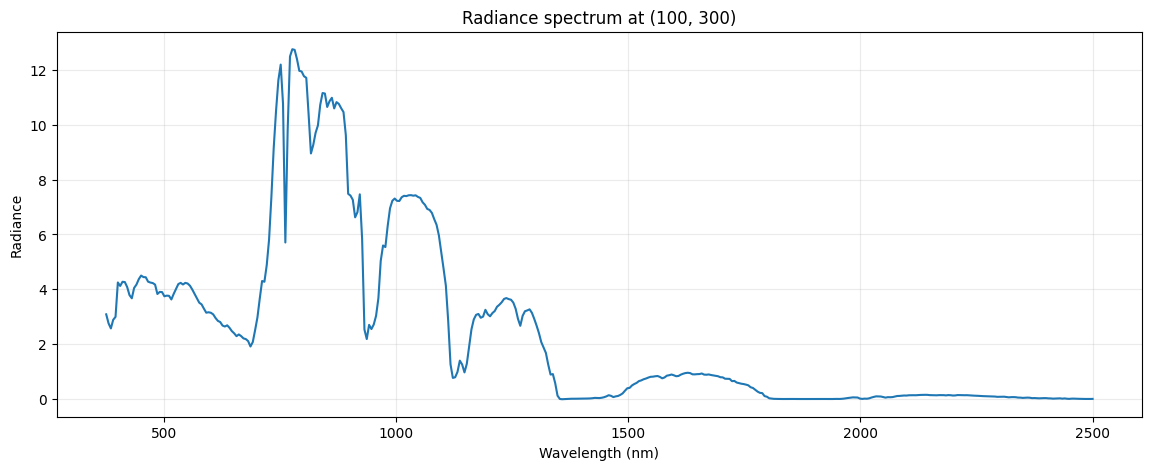

In [5]:
# Inspect one complete spectrum: this IS the vector x_{r,c} from Section 01
row, col = 100, 300
spectrum = np.asarray(rdn_memmap[row, col, :], dtype=np.float32).squeeze()
print("Shape:", spectrum.shape, "Finite:", np.isfinite(spectrum).sum())

plt.figure(figsize=(14, 5))
plt.plot(wavelengths, spectrum)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Radiance")
plt.title(f"Radiance spectrum at ({row}, {col})")
plt.grid(alpha=.25)
plt.show()

| おおよその波長範囲     | 主な吸収成分           | 主な起源                 |
| ------------- | ---------------- | -------------------- |
| 約400–700 nm   | 色素               | 植生、土壌、鉱物             |
| 約760 nm       | O₂               | 大気中の酸素               |
| 約900–1000 nm  | H₂O              | 水蒸気、大気および地表物質        |
| 約1200 nm      | H₂O              | 大気中の水蒸気、地表物質         |
| 約1400 nm      | **H₂O**          | 水による非常に強い吸収帯         |
| 約1900 nm      | **H₂O**          | 水による非常に強い吸収帯         |
| 約2000–2200 nm | H₂O + 鉱物         | 水、粘土鉱物、炭酸塩鉱物など       |
| 約2120–2485 nm | **CH₄ + その他の寄与** | CH₄検出・解析に利用するスペクトル領域 |


## 04. Radiance and wavelength calibration validation - 放射輝度と波長の校正の検証

The AVIRIS-NG radiance product is already instrument-calibrated. This notebook does not perform the radiometric calibration itself; it loads the calibrated radiance values supplied in the ENVI product.

The wavelength calibration is also provided by the ENVI header. The header contains the center wavelength corresponding to each spectral band, so wavelengths must be read from the metadata rather than inferred from the band index.

The code below therefore validates the calibration metadata by checking:

* that the number of wavelengths matches the number of spectral bands;
* that wavelengths are monotonically increasing;
* that the wavelength range is physically plausible;
* that an example radiance spectrum contains only finite values.

Because the instrument has a finite spectral response function, each measured spectral band represents a finite spectral interval rather than an infinitely narrow molecular line.

ハイパースペクトルデータでは、各バンドがどの波長に対応しているのかを正確に知る必要があります。そのため、波長をバンド番号から推定するのではなく、ENVIヘッダーに記録された校正済みの中心波長を使用します。

ここでは、放射輝度および波長の校正を新たに計算するのではなく、既に校正されたAVIRIS-NG製品を読み込み、ENVIメタデータに記録された校正情報の整合性を検証します。


In [6]:
# Read calibrated wavelength centers from the ENVI header
# wavelengths = np.asarray(rdn_img.bands.centers, dtype=np.float32)

# Open the calibrated radiance cube using memory mapping
# rdn_memmap = getattr(rdn_img, "open_memmap")()


print(
    "Header wavelengths are monotonically increasing:",
    np.all(np.diff(wavelengths) > 0)
)

print(
    "Header wavelength range (nm):",
    wavelengths.min(), "-", wavelengths.max()
)

print("These must NOT be treated as interchangeable.")

# Validate that every spectral band has one corresponding wavelength
check(
    "Wavelength count matches spectral bands",
    len(wavelengths) == rdn_img.shape[2],
    f"{len(wavelengths)} wavelengths vs {rdn_img.shape[2]} spectral bands"
)

# Validate that the wavelength range is physically plausible for AVIRIS-NG
check(
    "Wavelength range plausible",
    300 < wavelengths.min() < 500 and 2400 < wavelengths.max() < 2600,
    f"{wavelengths.min():.1f}-{wavelengths.max():.1f} nm"
)

# Validate that an example calibrated spectrum contains no NaN or Inf values
check(
    "Example spectrum fully finite",
    np.isfinite(spectrum).all(),
    f"{np.isfinite(spectrum).sum()}/{len(spectrum)}"
)

Header wavelengths are monotonically increasing: True
Header wavelength range (nm): 376.44 - 2500.12
These must NOT be treated as interchangeable.
[✓] Wavelength count matches spectral bands — 425 wavelengths vs 425 spectral bands
[✓] Wavelength range plausible — 376.4-2500.1 nm
[✓] Example spectrum fully finite — 425/425


True

## 05. CH₄ molecular absorption physics - メタン分子の吸収特性

Molecular transitions create characteristic absorption structures. Conceptually,

$$
R(\lambda)\approx C(\lambda)A_{CH4}(\lambda)+\epsilon(\lambda),
$$

where $C$ is broad background/continuum structure and $A_{CH4}$ is the methane absorption signature.

メタン（CH₄）分子は、特定の波長の電磁波を吸収します。

これは分子内部の振動・回転状態に対応する量子力学的な現象です。

したがって、CH₄が存在すると、その波長領域のスペクトルに特徴的な吸収構造が現れます。

本プロジェクトでは、特に

$$ 2120\ \mathrm{nm} \leq \lambda \leq 2485\ \mathrm{nm} $$

のスペクトル領域を解析します。

この領域には、CH₄検出に利用できるスペクトル情報が含まれています。

ただし、センサーが測定するスペクトルは「純粋なCH₄のスペクトル」ではありません。

実際の観測値には、

地表面の反射特性
大気
他の分子
太陽光
センサーの特性
ノイズ

などが含まれます。

したがって、CH₄の吸収信号を取り出すためには、背景スペクトルからCH₄に関連する変化を分離する必要があります。

[✓] CH4 spectral interval contains bands — 40 bands
[✓] CH4 wavelengths match spectrum — 40 wavelengths vs 40 radiance values
Bands: 40 range: 2204.6 - 2399.94 nm


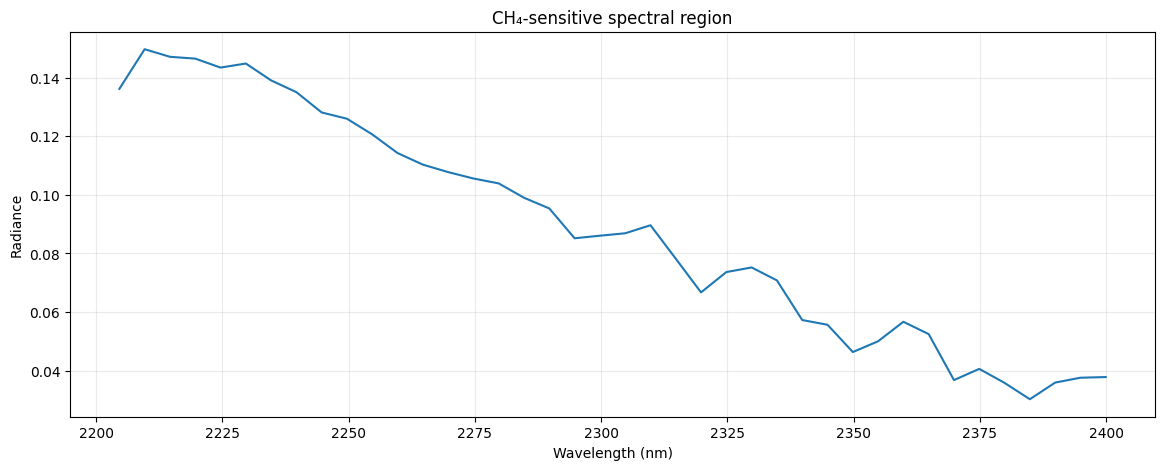

In [48]:
# CH4-sensitive spectral interval - include the full absorption window and some continuum on either side
CH4_MIN = 2200.0
CH4_MAX = 2400.0

ch4_mask = (wavelengths >= CH4_MIN) & (wavelengths <= CH4_MAX)
ch4_indices = np.where(ch4_mask)[0]
ch4_wavelengths = wavelengths[ch4_mask]

check(
    "CH4 spectral interval contains bands",
    len(ch4_indices) > 0,
    f"{len(ch4_indices)} bands"
)

check(
    "CH4 wavelengths match spectrum",
    len(ch4_wavelengths) == len(spectrum[ch4_mask]),
    f"{len(ch4_wavelengths)} wavelengths vs {len(spectrum[ch4_mask])} radiance values"
)

print(
    "Bands:", len(ch4_indices),
    "range:", ch4_wavelengths[0], "-", ch4_wavelengths[-1], "nm"
)

plt.figure(figsize=(14, 5))
plt.plot(ch4_wavelengths, spectrum[ch4_mask])
plt.xlabel("Wavelength (nm)")
plt.ylabel("Radiance")
plt.title("CH₄-sensitive spectral region")
plt.grid(alpha=.25)
plt.show()

In [8]:
check("CH4 wavelength range correct", ch4_wavelengths.min() >= CH4_MIN and ch4_wavelengths.max() <= CH4_MAX)

[✓] CH4 wavelength range correct


True

## 06. Beer–Lambert model

The fundamental attenuation model for the observed radiance is

$$
I(\lambda)=I_0(\lambda)e^{-\tau(\lambda)}
$$

where $I(\lambda)$ is the observed radiance and $ I_0(\lambda)$ is the background/continuum radiance estimated in the absence of CH₄ absorption.

The optical depth is

$$
\tau(\lambda)=\sigma(\lambda)NL.
$$

Therefore,

$$
-\ln\left(\frac{I}{I_0}\right)=\tau.
$$

Remote-sensing methane retrievals are commonly expressed as concentration-path length, e.g. ppm·m, rather than simply ppm.

光が吸収性物質を通過すると、放射輝度は減少します。この現象はBeer–Lambertの法則によって表現できます。

ここで、

$I_0(\lambda)$：CH₄吸収がない場合の背景・連続スペクトル（continuum）の放射輝度

$I(\lambda)$：実際に観測された放射輝度

$\tau(\lambda)$：光学的厚さ（optical depth）

です。


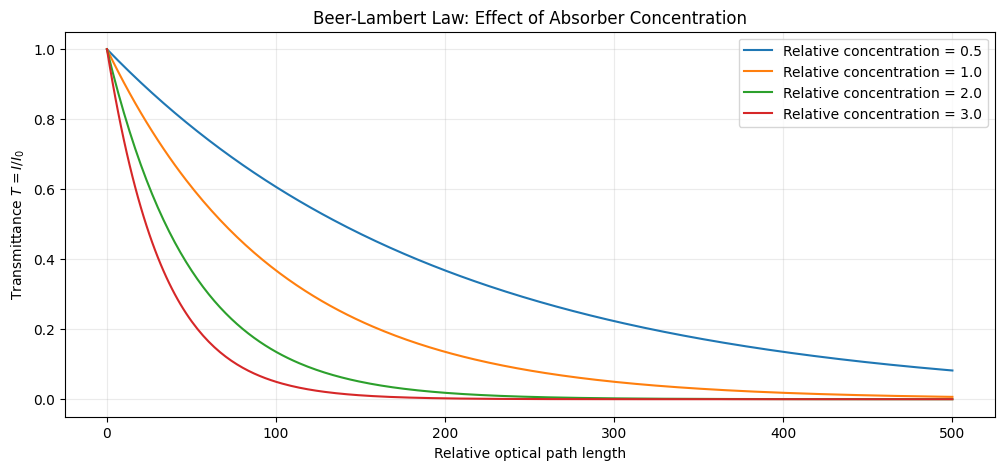

In [9]:
# --------------------------------------------------
# Synthetic Beer-Lambert demonstration
# --------------------------------------------------

# Relative optical path length
L = np.linspace(0, 500, 300)

# Relative absorber concentrations
concentrations = [0.5, 1.0, 2.0, 3.0]

# Arbitrary absorption coefficient
alpha = 0.01

plt.figure(figsize=(12, 5))

for C in concentrations:
    tau = alpha * C * L
    transmittance = np.exp(-tau)

    plt.plot(
        L,
        transmittance,
        label=f"Relative concentration = {C}"
    )

plt.xlabel("Relative optical path length")
plt.ylabel(r"Transmittance $T = I/I_0$")
plt.title("Beer-Lambert Law: Effect of Absorber Concentration")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 07. Continuum estimation - Continuumの推定

We estimate a smooth spectral continuum $C(\lambda)$, using a polynomial as a transparent baseline:

$$
C(\lambda)=a_0+a_1\lambda+a_2\lambda^2.
$$

This is an interpretation baseline, not a complete radiative-transfer model.



Beer–Lambertの式を使用するためには、吸収が存在しなかった場合のスペクトル $I_0$ を推定する必要があります。

しかし、実際の観測データから $I_0$ を直接測定することはできません。

そこで、観測スペクトルの大まかな形状を近似する continuum を作成します。

概念的には、

$$
R(\lambda) \approx C(\lambda)\cdot A_{CH4}(\lambda)
$$

のように、観測スペクトルは continuum と吸収成分の積として近似できます。

**重要な修正点 — Shoulder-band fitting**

単純に全波長域（CH₄吸収帯を含む区間）に多項式をフィットすると、continuum自体が吸収の影響を受けてしまいます。吸収帯の中の値も fit に使われるため、continuum が実際より低く推定され、結果として吸収深度が過小評価されます。これは一種の循環参照的な誤差です。

修正版では、CH₄の主吸収帯（2298–2358 nm, SWIR）を除いた**両肩（shoulder bands）**のみを使って continuum をフィットします:

$$
C(\lambda) = \text{polyfit}\Big(\{\lambda_i : \lambda_i \notin [2298,\ 2358]\text{ nm}\},\ \{L(\lambda_i)\},\ \text{degree}=2\Big)
$$

This is the same shoulder-band principle used in the CIBR (Continuum Interpolated Band Ratio) method — the continuum is estimated only from bands *outside* the feature it is meant to represent, so it is never contaminated by the absorption itself.

```test
Observed spectrum

Intensitate
   │
   │       /\              ← emisie
   │      /  \
   │─────/────\──────────────── Continuum
   │              \____/      ← absorbție
   │
   └──────────────────────────→ λ
```

In [ ]:
# Set a fixed random seed to make the random pixel sampling reproducible
RANDOM_STATE = 42
# Sample at most 5,000 pixels from the complete image
NO_PIXELS = 5000
# Define the wavelength interval containing the main CH4 absorption feature
CH4_ABS_MIN, CH4_ABS_MAX = 2298.0, 2358.0

# Wavelength vector corresponding to the selected CH4 spectral bands
# ch4_wavelengths

# Get the spatial and spectral dimensions of the radiance cube
n_lines, n_samples, n_bands = rdn_memmap.shape

# Create a reproducible random number generator
rng = np.random.default_rng(RANDOM_STATE)

# define the number of pixels to sample for PCA, limited by the total number of pixels in the image
n_pca = min(NO_PIXELS, n_lines * n_samples)

# Randomly select pixel indices from the flattened spatial dimensions
ids = rng.choice(n_lines * n_samples, n_pca, replace=False)

# Convert flattened indices back to image row and column coordinates
rows_pca, cols_pca = ids // n_samples, ids % n_samples

# Allocate an array for the sampled CH4-region radiance spectra
Xp = np.empty((n_pca, len(ch4_indices)), dtype=np.float32)

# Extract the radiance spectrum at the selected CH4 wavelengths for each pixel
for i, (r, c) in enumerate(zip(rows_pca, cols_pca)):
    Xp[i] = np.asarray(rdn_memmap[r, c, ch4_indices], dtype=np.float32)

# Remove pixels containing NaN or infinite radiance values
# Remove pixels containing non-positive radiance values
# Positive radiance is required for subsequent logarithmic operations
finite_mask = np.isfinite(Xp).all(axis=1) & (Xp > 0).all(axis=1)
Xp = Xp[finite_mask]

rows_pca = rows_pca[finite_mask]
cols_pca = cols_pca[finite_mask]

# Verify that a sufficient number of valid pixels remain
check("Xp sampled pixels non-empty", Xp.shape[0] > 100, f"{Xp.shape[0]} pixels")

# Verify that all remaining radiance values are finite and positive
check("Xp fully finite and positive", np.isfinite(Xp).all() and (Xp > 0).all())



# Select wavelengths outside the main CH4 absorption window.
# These shoulder bands are used to estimate the spectral continuum.
shoulder_mask = ~((ch4_wavelengths >= CH4_ABS_MIN) & (ch4_wavelengths <= CH4_ABS_MAX))

# Verify that the shoulder region contains most of the available spectral bands
check("Shoulder mask covers most bands (not just the absorption window)",
      shoulder_mask.sum() > 0.5 * len(ch4_wavelengths), f"{shoulder_mask.sum()}/{len(ch4_wavelengths)} bands")


def continuum_remove_batch(Xp, ch4_wavelengths, shoulder_mask, degree=2):
    # Number of spectra to process
    n_pixels = Xp.shape[0]

    # Allocate an array for continuum-normalized spectra
    ratio = np.empty_like(Xp)

    # Process each pixel spectrum independently
    for i in range(n_pixels):
        y = Xp[i]

        # Use only valid shoulder-band measurements to estimate the continuum
        ok = shoulder_mask & np.isfinite(y)

        # Fit a polynomial continuum to the shoulder bands
        coeffs = np.polyfit(ch4_wavelengths[ok], y[ok], degree)

        # Evaluate the fitted continuum across the complete CH4 spectral range
        cont = np.polyval(coeffs, ch4_wavelengths)

        # Divide the observed radiance by the estimated continuum.
        # The resulting spectrum is approximately 1 outside absorption features
        # and falls below 1 where CH4 absorption occurs.
        ratio[i] = y / np.clip(cont, 1e-6, None)

    return ratio


# Estimate and remove the spectral continuum for all sampled pixels
Xp_ratio = continuum_remove_batch(Xp, ch4_wavelengths, shoulder_mask)


# Verify that the continuum-normalized spectra contain only finite values
check("Xp_ratio finite everywhere", np.isfinite(Xp_ratio).all())

# On the shoulder bands, the continuum-normalized spectrum should be close to 1
check("Xp_ratio centered near 1.0 on shoulder bands (sanity)",
      abs(Xp_ratio[:, shoulder_mask].mean() - 1.0) < 0.05,
      f"mean={Xp_ratio[:, shoulder_mask].mean():.4f} (expected ~1.0)")

# Inside the CH4 absorption window, radiance should be lower relative to the continuum.
# Therefore, the continuum-normalized ratio should generally be lower than on the shoulders.
check("Xp_ratio dips below shoulder mean inside CH4 window (absorption visible)",
      Xp_ratio[:, ~shoulder_mask].mean() <= Xp_ratio[:, shoulder_mask].mean(),
      f"inside={Xp_ratio[:, ~shoulder_mask].mean():.4f}, shoulder={Xp_ratio[:, shoulder_mask].mean():.4f}")




[✓] Xp sampled pixels non-empty — 4959 pixels
[✓] Xp fully finite and positive
[✓] Shoulder mask covers most bands (not just the absorption window) — 28/40 bands
[✓] Xp_ratio finite everywhere
[✓] Xp_ratio centered near 1.0 on shoulder bands (sanity) — mean=1.0010 (expected ~1.0)
[✓] Xp_ratio dips below shoulder mean inside CH4 window (absorption visible) — inside=0.9931, shoulder=1.0010


True

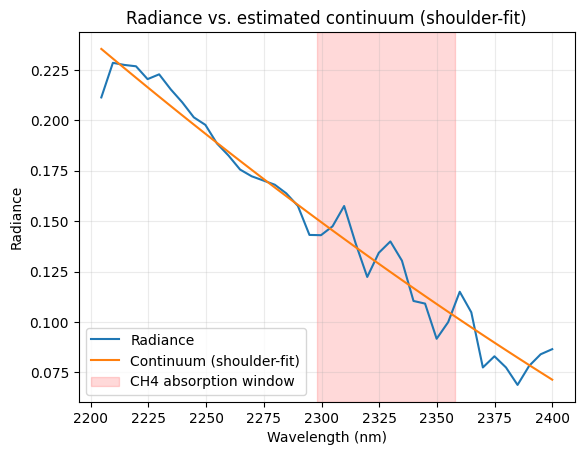

In [11]:
# Plot the original radiance spectrum and its estimated continuum for one example pixel
example_idx = 0

# Select one sampled pixel spectrum
y_example = Xp[example_idx]

# Use only the shoulder bands for continuum fitting
ok = shoulder_mask & np.isfinite(y_example)

# Fit a second-degree polynomial continuum to the shoulder radiance
coeffs_example = np.polyfit(ch4_wavelengths[ok], y_example[ok], 2)

# Evaluate the fitted continuum over the complete spectral range
continuum_example = np.polyval(coeffs_example, ch4_wavelengths)

# Plot the observed radiance spectrum
plt.plot(ch4_wavelengths, y_example, label="Radiance")

# Plot the estimated spectral continuum
plt.plot(ch4_wavelengths, continuum_example, label="Continuum (shoulder-fit)")

# Highlight the main CH4 absorption window
plt.axvspan(CH4_ABS_MIN, CH4_ABS_MAX,
            alpha=0.15,
            color='red',
            label="CH4 absorption window")

# Label the axes
plt.xlabel("Wavelength (nm)")
plt.ylabel("Radiance")

# Add a descriptive title
plt.title("Radiance vs. estimated continuum (shoulder-fit)")

# Display the legend and grid
plt.legend()
plt.grid(alpha=.25)

# Render the plot
plt.show()

## 08. Per-pixel absorption proxy - Demonstration - 画素ごとの吸収プロキシ（デモンストレーション）

For each sampled pixel, the continuum-normalized absorption proxy is

サンプリングした各画素について、連続スペクトル（continuum）で正規化した吸収プロキシを次式で定義する。

$$
A(\lambda)= -\ln\left( \frac{L(\lambda)}{C(\lambda)} \right).
$$

where $L(\lambda)$ is the measured radiance and $C(\lambda)$ is the estimated spectral continuum.

ここで、$L(\lambda)$ は観測放射輝度、$C(\lambda)$ は推定されたスペクトル連続成分（continuum）を表す。

For absorption,

吸収が生じている場合、

$$
L(\lambda) < C(\lambda) \quad\Rightarrow\quad A(\lambda) > 0.
$$

The absorption proxy is calculated for all 5,000 sampled pixels in Section 07. One representative pixel is presented here for demonstration only.

この吸収プロキシは、Section 07で抽出した5,000画素すべてについて計算される。ここでは、その計算方法を示すために代表的な1画素のみを例として可視化する。

The resulting $A(\lambda)$ is a **continuum-normalized absorption proxy**, not a direct CH4 concentration estimate.

得られた $A(\lambda)$ は**連続スペクトル正規化吸収プロキシ**であり、CH4 濃度を直接推定する値ではない。


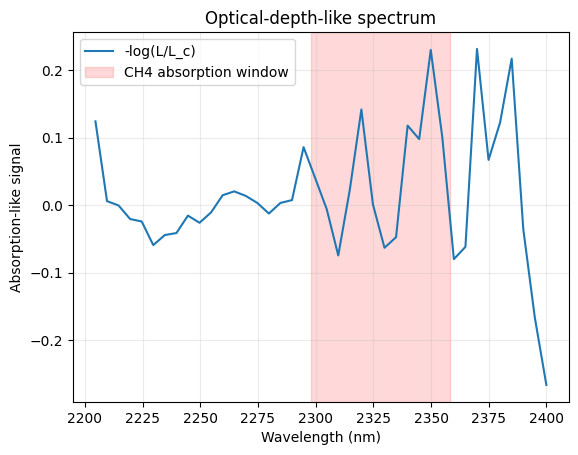

In [12]:

spec_ch4 = spectrum[ch4_mask].astype(float)

def polynomial_continuum_shoulder(ch4_wavelengths, y, shoulder_mask, degree=2):
    ok = np.isfinite(ch4_wavelengths) & np.isfinite(y) & shoulder_mask
    coeffs = np.polyfit(ch4_wavelengths[ok], y[ok], degree)
    return np.polyval(coeffs, ch4_wavelengths)

continuum = polynomial_continuum_shoulder(ch4_wavelengths, spec_ch4, shoulder_mask)

absorption = -np.log(np.clip(spec_ch4 / continuum, 1e-6, None))

plt.plot(ch4_wavelengths, absorption, label="-log(L/L_c)")
plt.axvspan(CH4_ABS_MIN, CH4_ABS_MAX, alpha=0.15, color='red', label="CH4 absorption window")
plt.xlabel("Wavelength (nm)"); plt.ylabel("Absorption-like signal")
plt.title("Optical-depth-like spectrum")
plt.legend(); plt.grid(alpha=.25); plt.show()

  ## 09. Fourier spectral analysis - Demonstration / フーリエスペクトル解析 => 実例

For a sampled spectrum $x_n$,

サンプリングされたスペクトル $x_n$ に対して、

$$
X_k=\sum_{n=0}^{N-1}x_ne^{-i2\pi kn/N}.
$$

We inspect $|X_k|$ to diagnose broad versus rapid spectral variations, noise and smoothing effects.

$|X_k|$ を調べることで、緩やかな変化と急激な変化、ノイズ、平滑化の影響を診断する。

FFT is **not** presented as the primary methane retrieval method; wavelength-domain spectral matching and matched filtering (Sections 12-13) are more directly tied to the CH₄ absorption physics.

FFTは**メタンの主要な検出手法として提示されているわけではない**。波長領域でのスペクトルマッチングおよびmatched filter（セクション12〜13）の方が、CH₄吸収の物理現象により直接的に関連している。

**Why FFT is not the right tool here:** CH₄ absorption is not a periodic phenomenon in the wavelength domain — it is a single, localized dip confined to the 2298–2358 nm window, not a repeating oscillatory pattern. FFT decomposes a signal into sinusoidal frequency components, which is well suited to detecting periodicities (e.g. interference fringes, repetitive sensor artifacts) or filtering high-frequency noise. A single localized absorption feature has no meaningful periodic structure to extract this way. Matched filtering (Section 13) and continuum removal (Sections 07–08) are the physically appropriate tools instead, since they compare the observed spectral *shape* directly against the target shape in the wavelength domain — which is what actually characterizes molecular absorption.

**なぜFFTがここでは適切な手法ではないのか：** CH₄の吸収は波長領域において周期的な現象ではない — 2298〜2358 nmの範囲に局在する単一の吸収の落ち込みであり、繰り返し起こる振動的なパターンではない。FFTは信号を正弦波状の周波数成分に分解する手法であり、周期性の検出（例：干渉縞、繰り返し発生するセンサーのアーティファクト）や高周波ノイズの除去には適している。しかし、局在した単一の吸収特徴には、この方法で抽出すべき意味のある周期構造は存在しない。代わりに、matched filter（セクション13）やcontinuum removal（セクション07〜08）が物理的に適切な手法である。これらは、観測されたスペクトルの**形状**を波長領域で直接、目標とする形状と比較するものであり、分子吸収を実際に特徴づけるのはまさにこの形状だからである。

For this reason, this section is included for demonstration only (showing how FFT can be applied to a spectral signal and how to interpret its output), not as a functional step in the retrieval pipeline. No result from this section is used in any later section of the notebook.

このため、本セクションは**デモンストレーション目的のみ**で含まれている（FFTをスペクトル信号にどのように適用し、その出力をどう解釈するかを示すため）。retrievalパイプラインの機能的なステップとしては使用されていない。本セクションの結果は、ノートブックの以降のいかなるセクションでも使用されない。

Note: AVIRIS-NG band centers are not guaranteed to be perfectly equally spaced (especially across the VNIR/SWIR spectrometer join), so the frequency axis below uses the *median* spacing as an approximation — treat it as diagnostic, not a rigorously calibrated frequency axis.

注：AVIRIS-NGのバンド中心波長は、必ずしも完全に等間隔であるとは限らない（特にVNIR/SWIRスペクトロメータの接合部において）。そのため、以下の周波数軸は*中央値*の間隔を近似として使用している — これは診断的な目的のものであり、厳密に校正された周波数軸ではないことに注意されたい。

[✓] Wavelength grid approximately uniform for FFT — median Δλ=5.010010 nm, range=5.000000 - 5.010010 nm


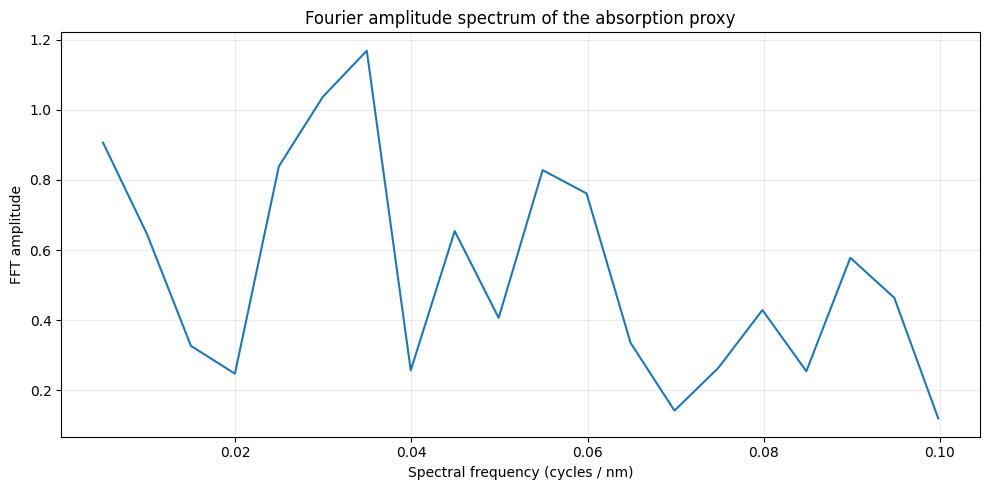

In [13]:
delta = np.diff(ch4_wavelengths)

check(
    "Wavelength grid approximately uniform for FFT",
    np.allclose(
        delta,
        np.median(delta),
        rtol=5e-3,
        atol=1e-6
    ),
    f"median Δλ={np.median(delta):.6f} nm, "
    f"range={delta.min():.6f} - {delta.max():.6f} nm"
)

# FFT requires an approximately uniformly sampled wavelength grid.
delta_lambda = float(np.median(np.diff(ch4_wavelengths)))

# Remove the DC component before computing the FFT.
signal = np.nan_to_num(absorption - np.nanmean(absorption))

fft_vals = np.fft.rfft(signal)

freq = np.fft.rfftfreq(
    len(signal),
    d=delta_lambda
)

amplitude = np.abs(fft_vals)

plt.figure(figsize=(10, 5))

plt.plot(freq[1:], amplitude[1:])

plt.title("Fourier amplitude spectrum of the absorption proxy")
plt.xlabel("Spectral frequency (cycles / nm)")
plt.ylabel("FFT amplitude")

plt.grid(alpha=.25)
plt.tight_layout()
plt.show()

## 10. PCA / Covariance Analysis — 5,000 Spectra / 5,000スペクトル

PCA is applied to the 5,000 sampled spectra to identify the dominant modes of spectral variability and redundancy.

PCAは、5,000個のサンプルスペクトルに適用し、スペクトル変動の主要な成分と冗長性を調べる。

After centering:

$$
X_c=X-\mu
$$

The covariance matrix is:

$$
C=\frac{1}{N-1}X_c^T X_c
$$

PCA solves:

$$
Cv_i=\lambda_i v_i
$$

The eigenvectors $v_i$ represent the principal spectral directions, while $\lambda_i$ represents the variance associated with each component.

固有ベクトル $v_i$ は主要なスペクトル方向を表し、固有値 $\lambda_i$ は各成分が持つ分散量を表す。

PCA is used here as a **diagnostic tool**, not as a requirement for Random Forest.

ここでのPCAは**診断・解析用**であり、Random Forestに必須ではない。

### PCA on Raw Radiance / Raw RadianceのPCA

A dominant PC1 indicates that the spectra are strongly correlated and that broadband variability dominates the data.

PC1が支配的である場合、スペクトル間の相関が強く、広帯域の変動がデータを支配していることを示す。

This variability may include surface albedo, illumination, viewing geometry, and atmospheric effects.

この変動には、地表アルベド、照明条件、観測幾何、 大気効果などが含まれる可能性がある。

### Modification 1 — Log-Radiance / 対数放射輝度

Under a simplified multiplicative model,

$$
L(\lambda)\approx A\,S(\lambda)\,T(\lambda)
$$

the logarithm gives

$$
\ln L(\lambda)=\ln A+\ln S(\lambda)+\ln T(\lambda).
$$

The logarithm converts multiplicative factors into additive terms, but **does not remove albedo or illumination effects**.

対数変換は乗算的な要因を加算的な要因に変換するが、**アルベドや照明の影響そのものを除去するものではない**。

For the present data, PC1 remains approximately 99.1%, indicating that log-radiance alone does not sufficiently reduce broadband variability.

本データではPC1が約99.1%であり、対数変換だけでは広帯域変動を十分に低減できないことを示す。

### Modification 2 — Continuum Removal / Continuum除去

The local continuum is estimated from spectral regions outside the CH$_4$ absorption window:

$$
C(\lambda)=\text{estimated local continuum}
$$

The continuum-normalized spectrum is:

$$
R(\lambda)=\frac{L(\lambda)}{C(\lambda)}
$$

This reduces sloch4_wavelengthsy varying broadband effects and emphasizes localized spectral structure.

これにより、緩やかに変化する広帯域成分を低減し、局所的なスペクトル構造を強調する。

The corresponding absorption proxy is:

$$
A(\lambda)=-\ln\left(\frac{L(\lambda)}{C(\lambda)}\right)
$$

The purpose of continuum removal is therefore to **reduce broadband background variability**, not to completely eliminate albedo, illumination, or atmospheric effects.

したがって、Continuum除去の目的は、アルベド、照明、大気効果を完全に除去することではなく、**広帯域の背景変動を低減すること**である。


Explained variance (log-radiance): [0.6980252  0.06991838 0.04903483 0.02738351 0.0225512 ]
Cumulative: [0.6980252  0.7679436  0.81697845 0.84436196 0.86691314]


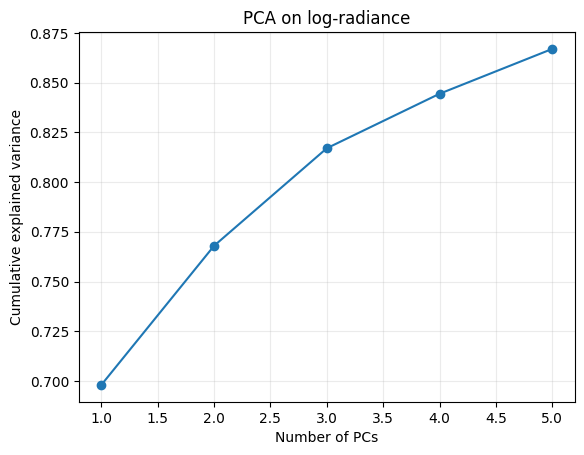

[✓] Explained variance sums to ≤ 1.0 (log)
[✓] PCA components orthonormal (log)

Explained variance (continuum-removed): [0.24973209 0.15758453 0.08483975 0.06704766 0.05971708]
Cumulative: [0.24973209 0.40731663 0.4921564  0.55920404 0.6189211 ]
[✓] Explained variance sums to ≤ 1.0 (ratio)
[✓] Explained variance ratios monotonic decreasing (ratio)
[✓] PCA components orthonormal (ratio)


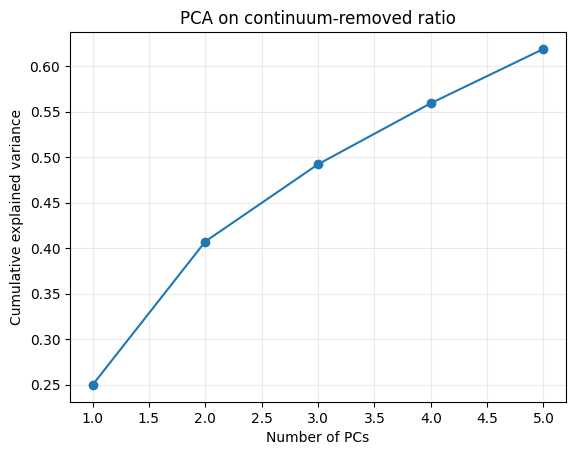

=== PCA comparison ===

Log-radiance:
Explained variance: [0.6980252  0.06991838 0.04903483 0.02738351 0.0225512 ]
Cumulative: [0.6980252  0.7679436  0.81697845 0.84436196 0.86691314]

Continuum-removed ratio:
Explained variance: [0.24973209 0.15758453 0.08483975 0.06704766 0.05971708]
Cumulative: [0.24973209 0.40731663 0.4921564  0.55920404 0.6189211 ]


In [49]:
# --- Section 10: PCA / Covariance Analysis ---
# Reuses Xp and Xp_ratio calculated in Section 07 — no resampling from memmap.

# Modification 1 — log-radiance
Xp_log = np.log(Xp)
Xp_log_centered = Xp_log - Xp_log.mean(axis=1, keepdims=True)

pca = PCA(
    n_components=min(5, Xp_log_centered.shape[0], Xp_log_centered.shape[1]),
    random_state=RANDOM_STATE
)
scores = pca.fit_transform(Xp_log_centered)

print("Explained variance (log-radiance):", pca.explained_variance_ratio_)
print("Cumulative:", np.cumsum(pca.explained_variance_ratio_))

plt.plot(
    np.arange(1, len(pca.explained_variance_ratio_) + 1),
    np.cumsum(pca.explained_variance_ratio_),
    marker="o"
)
plt.xlabel("Number of PCs")
plt.ylabel("Cumulative explained variance")
plt.title("PCA on log-radiance")
plt.grid(alpha=.25)
plt.show()

check(
    "Explained variance sums to ≤ 1.0 (log)",
    np.cumsum(pca.explained_variance_ratio_)[-1] <= 1.0 + 1e-6
)

check(
    "PCA components orthonormal (log)",
    np.allclose(
        pca.components_ @ pca.components_.T,
        np.eye(pca.components_.shape[0]),
        atol=1e-4
    )
)

# Modification 2 — continuum-removed ratio
pca_ratio = PCA(
    n_components=min(5, Xp_ratio.shape[0], Xp_ratio.shape[1]),
    random_state=RANDOM_STATE
)
scores_ratio = pca_ratio.fit_transform(Xp_ratio)

print("\nExplained variance (continuum-removed):",
      pca_ratio.explained_variance_ratio_)
print("Cumulative:",
      np.cumsum(pca_ratio.explained_variance_ratio_))

check(
    "Explained variance sums to ≤ 1.0 (ratio)",
    np.cumsum(pca_ratio.explained_variance_ratio_)[-1] <= 1.0 + 1e-6
)

check(
    "Explained variance ratios monotonic decreasing (ratio)",
    np.all(np.diff(pca_ratio.explained_variance_ratio_) <= 1e-9)
)

check(
    "PCA components orthonormal (ratio)",
    np.allclose(
        pca_ratio.components_ @ pca_ratio.components_.T,
        np.eye(pca_ratio.components_.shape[0]),
        atol=1e-4
    )
)

plt.plot(
    np.arange(1, len(pca_ratio.explained_variance_ratio_) + 1),
    np.cumsum(pca_ratio.explained_variance_ratio_),
    marker="o"
)
plt.xlabel("Number of PCs")
plt.ylabel("Cumulative explained variance")
plt.title("PCA on continuum-removed ratio")
plt.grid(alpha=.25)
plt.show()
print("=== PCA comparison ===")

print("\nLog-radiance:")
print("Explained variance:", pca.explained_variance_ratio_)
print("Cumulative:", np.cumsum(pca.explained_variance_ratio_))

print("\nContinuum-removed ratio:")
print("Explained variance:", pca_ratio.explained_variance_ratio_)
print("Cumulative:", np.cumsum(pca_ratio.explained_variance_ratio_))


PCA nu demonstrează că variația rămasă este CH₄. Poate conține CH₄, alte gaze, zgomot, variații ale suprafeței etc.

PCA shows that continuum removal substantially redistributes spectral variance: PC1 decreases from 69.8% for log-radiance to 25.0% for the continuum-normalized ratio. This indicates reduced dominance of broadband spectral variability and greater preservation of localized spectral structure. PCA is therefore used as a diagnostic to evaluate the effect of preprocessing, not as a CH₄ detector.

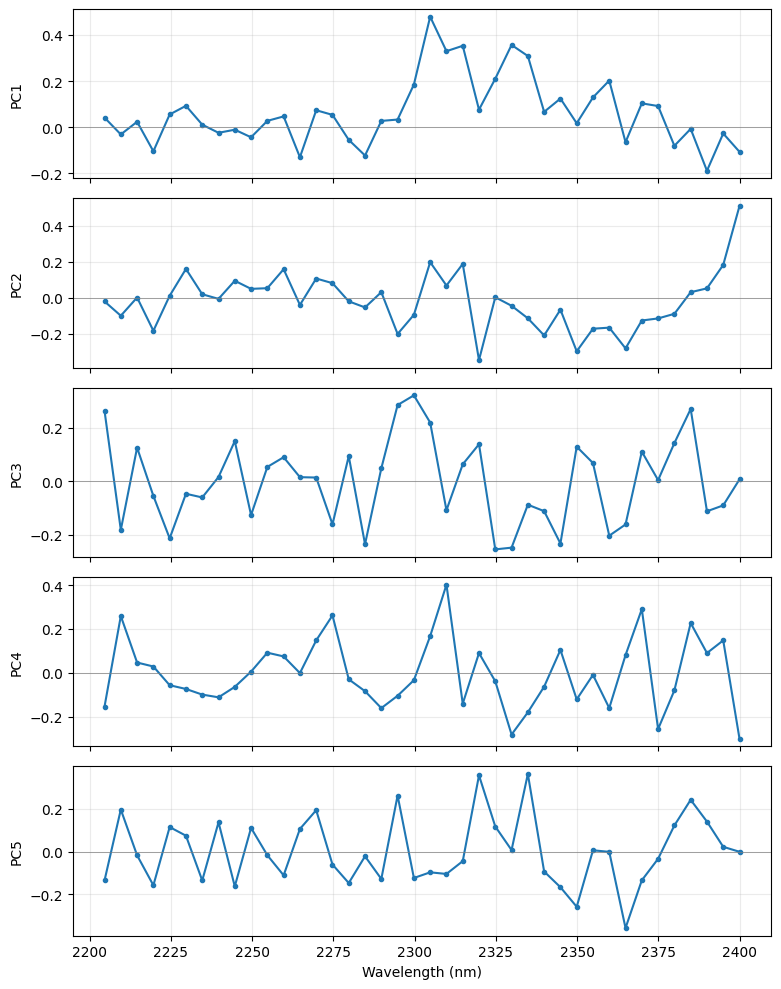

In [15]:
wavelengths_ch4 = wavelengths[ch4_indices]

fig, axes = plt.subplots(
    len(pca_ratio.components_),
    1,
    figsize=(8, 2 * len(pca_ratio.components_)),
    sharex=True
)

for i, ax in enumerate(axes):
    ax.plot(wavelengths_ch4, pca_ratio.components_[i], marker=".")
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.set_ylabel(f"PC{i+1}")
    ax.grid(alpha=.25)

axes[-1].set_xlabel("Wavelength (nm)")
plt.tight_layout()
plt.show()

PC1 is monoton descending without pick, so appear so be albedo effect, so is needed a normalization or?

In [16]:
check("Explained variance sums to ≤ 1.0", np.cumsum(pca.explained_variance_ratio_)[-1] <= 1.0 + 1e-6)
check("Explained variance ratios monotonic decreasing", np.all(np.diff(pca.explained_variance_ratio_) <= 1e-9))
check("PCA components orthonormal", np.allclose(pca.components_ @ pca.components_.T, np.eye(pca.components_.shape[0]), atol=1e-4))


[✓] Explained variance sums to ≤ 1.0
[✓] Explained variance ratios monotonic decreasing
[✓] PCA components orthonormal


True

## 11. CH₄ Unit Absorption Spectrum & Spectral Similarity — CH₄ 単位吸収スペクトルとスペクトル類似度

The `*_ch4_ua.txt` file is treated as a **modeled CH₄ unit-absorption spectrum**, not as measured ground truth.

We extract its wavelength and absorption signal, verify wavelength overlap with AVIRIS-NG, and interpolate the reference spectrum onto the AVIRIS-NG wavelength grid. The resulting `target` provides a **CH₄ reference spectral signature** for comparison.

$$
\text{UA spectrum}
\;\rightarrow\;
\text{wavelength alignment}
\;\rightarrow\;
\boxed{\text{CH}_4\text{ reference target}}
$$

It is used for spectral comparison, not as an independent measurement of atmospheric CH₄ concentration.

**日本語**

`*_ch4_ua.txt` ファイルは、**モデル化された CH₄ の単位吸収スペクトル**として扱い、実測された ground truth とはみなしません。

波長と吸収信号を抽出し、AVIRIS-NG との波長範囲の重なりを確認した後、AVIRIS-NG の波長グリッドへ補間します。これにより、スペクトル比較に使用する **CH₄ の参照スペクトル `target`** を作成します。

これは大気中 CH₄ 濃度の独立した実測値ではありません。

### Spectral similarity baseline

The measured spectrum \(x\) is compared with the CH₄ reference spectrum \(s\) using two simple baselines:

**Cosine similarity** measures overall spectral shape similarity.

$$
\cos\theta=
\frac{x^Ts}{\|x\|\|s\|}
$$

**Pearson correlation** measures similarity in the wavelength-by-wavelength variation pattern.

$$
\rho=
\frac{\sum_i(x_i-\bar{x})(s_i-\bar{s})}
{\sqrt{\sum_i(x_i-\bar{x})^2}
 \sqrt{\sum_i(s_i-\bar{s})^2}}
$$

These metrics provide **baseline spectral similarity scores** before applying more advanced retrieval or machine-learning methods.

**日本語**

測定スペクトル \(x\) と CH₄ 参照スペクトル \(s\) を、2つの基本的な指標で比較します。

* **コサイン類似度**：スペクトル全体の形状の類似性を評価する。
* **ピアソン相関係数**：波長に対する変化パターンの類似性を評価する。

これらは、高度な retrieval や機械学習を適用する前の **スペクトル類似度のベースライン**として使用します。


In [17]:
# --------------------------------------------------
# Load CH4 Unit Absorption (UA) reference spectrum
# --------------------------------------------------

# import the UA file, which contains the reference CH4 absorption spectrum
ua = np.loadtxt(UA_FILE)

print("UA shape:", ua.shape)
print("\nFirst 20 rows:")
print(ua[:20])

if ua.ndim == 2 and ua.shape[1] >= 3:

    # UA file format:
    # column 0 = index
    # column 1 = wavelength [nm]
    # column 2 = UA signal

    ua_wavelength = ua[:, 1].astype(np.float32)
    ua_signal = ua[:, 2].astype(np.float32)

    print("\nUA wavelength range:")
    print("min:", ua_wavelength.min())
    print("max:", ua_wavelength.max())

    print("\nUA signal range:")
    print("min:", ua_signal.min())
    print("max:", ua_signal.max())
    print("std:", ua_signal.std())

    # --------------------------------------------------
    # Check wavelength overlap with AVIRIS-NG
    # --------------------------------------------------

    print("\nAVIRIS CH4 wavelength range:")
    print(
        ch4_wavelengths.min(),
        "-",
        ch4_wavelengths.max(),
        "nm"
    )

    overlap_min = max(
        ua_wavelength.min(),
        ch4_wavelengths.min()
    )

    overlap_max = min(
        ua_wavelength.max(),
        ch4_wavelengths.max()
    )

    print("\nWavelength overlap:")
    print(overlap_min, "-", overlap_max, "nm")

    if overlap_min >= overlap_max:
        raise ValueError("No wavelength overlap between UA and AVIRIS.")

    # --------------------------------------------------
    # Validate UA wavelength grid
    # --------------------------------------------------

    check(
        "UA wavelengths strictly increasing",
        np.all(np.diff(ua_wavelength) > 0)
    )

    # --------------------------------------------------
    # Interpolate UA target onto AVIRIS wavelength grid
    # --------------------------------------------------

    target = np.interp(
        ch4_wavelengths,
        ua_wavelength,
        ua_signal
    )

    print("\nAligned CH4 target:")
    print("min:", target.min())
    print("max:", target.max())
    print("std:", target.std())

    if target.std() == 0:
        raise ValueError(
            "Aligned CH4 target is constant."
        )

else:
    raise ValueError(
        f"Unexpected UA file shape: {ua.shape}. "
        "Expected at least 3 columns."
    )

UA shape: (212, 3)

First 20 rows:
[[ 1.00000000e+00  1.44329000e+03 -4.88863792e-03]
 [ 2.00000000e+00  1.44830000e+03 -4.41333372e-03]
 [ 3.00000000e+00  1.45330000e+03 -3.16741737e-03]
 [ 4.00000000e+00  1.45831000e+03 -2.74717459e-03]
 [ 5.00000000e+00  1.46332000e+03 -2.05611880e-03]
 [ 6.00000000e+00  1.46833000e+03 -2.59721722e-03]
 [ 7.00000000e+00  1.47334000e+03 -3.09031876e-03]
 [ 8.00000000e+00  1.47835000e+03 -3.50348698e-03]
 [ 9.00000000e+00  1.48336000e+03 -1.89853855e-03]
 [ 1.00000000e+01  1.48836000e+03 -1.23623782e-03]
 [ 1.10000000e+01  1.49337000e+03 -1.00269285e-03]
 [ 1.20000000e+01  1.49838000e+03 -6.85436302e-04]
 [ 1.30000000e+01  1.50339000e+03 -5.46728552e-04]
 [ 1.40000000e+01  1.50840000e+03 -4.96329158e-04]
 [ 1.50000000e+01  1.51341000e+03 -3.95588926e-04]
 [ 1.60000000e+01  1.51842000e+03 -2.97705759e-04]
 [ 1.70000000e+01  1.52343000e+03 -2.14995438e-04]
 [ 1.80000000e+01  1.52843000e+03 -1.59613017e-04]
 [ 1.90000000e+01  1.53344000e+03 -1.19191136e-

## 12. Matched-filter mathematics

A simplified matched-filter score is

$$
MF(x)=\frac{s^TC^{-1}x}{s^TC^{-1}s},
$$

where $s$ is the target and $C$ is background covariance.

The inverse covariance downweights spectral directions that are naturally variable in the background. Raw radiance is on a large, uneven scale across bands, which leaves $C$ badly conditioned and its inverse prone to overflow — so bands are standardized first, and the ridge added for numerical stability is scaled to the matrix's own magnitude rather than a fixed constant.



元のコードでは、標準化（z-score）は行っていましたが、**対数変換は行っていませんでした**。

$$
X_z = \frac{X - \mu}{\sigma}
$$

z-scoreは各バンドを列単位で中心化・スケーリングしますが、ピクセルごとの**乗算的な明るさの違い（albedo）は除去しません**。

**修正 — Log-radianceに対してmatched filterを適用**

AVIRIS-NGの実運用アルゴリズム（Thompson et al.）と同様、matched filterはlog-radiance空間で計算するのが標準的です:

$$
x_{\log} = \ln(L),\qquad
\mu_{\log} = \mathbb{E}[x_{\log}],\qquad
C_{\log} = \text{Cov}(x_{\log})
$$

$$
MF(x) = \frac{s^T C_{\log}^{-1}(x_{\log}-\mu_{\log})}{s^T C_{\log}^{-1}s}
$$

target $s$（CH₄ unit absorption spectrum）は元々 optical-depth的な量なので、変換は不要です — log空間とすでに整合しています。

この修正により、共分散行列 $C_{\log}$ がalbedoの変動をより適切に捉え、ホワイトニング（$C^{-1}$による重み付け）がalbedo方向の変動をより効果的に抑制できるようになります。

### Interpretation — 解釈

* **High MF score** → the spectrum is more compatible with the CH₄ signature → **more likely to be a CH₄ candidate**.
  **MFスコアが高い** → スペクトルがCH₄の特徴とより一致する → **CH₄の候補である可能性が高い**。

* **Low MF score** → low compatibility with the CH₄ signature.
  **MFスコアが低い** → CH₄の特徴との適合性が低い。

* **Negative MF score** → the spectrum varies in the opposite direction to the expected CH₄ signature.
  **MFスコアが負** → スペクトルの変化が、想定されるCH₄の特徴とは逆方向である。


Matched-filter denominator (s^T C^-1 s): 2473.8085540893435
Matched-filter score for the example pixel: -0.023789991689166574
Finite scores: 500/500


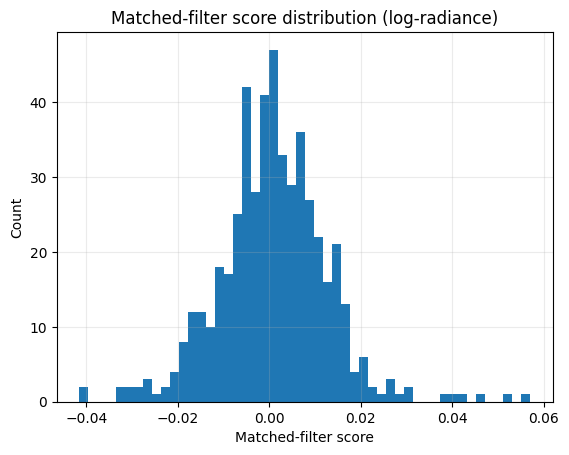

In [18]:
if target is not None:
    # Calculate the mean spectrum and standard deviation for each wavelength
    Xp_mean = Xp_log.mean(axis=0)
    Xp_std = Xp_log.std(axis=0)

    # Avoid division by zero for bands with zero variance
    Xp_std_safe = np.where(Xp_std > 0, Xp_std, 1.0)

    # Standardize the background spectra band-by-band (z-score)
    Xp_z = (Xp_log - Xp_mean) / Xp_std_safe

    # Estimate spectral covariance of the background
    C_bg = np.cov(Xp_z, rowvar=False)

    # Add a small ridge term to improve numerical stability
    ridge = 1e-3 * np.trace(C_bg) / C_bg.shape[0]
    C_bg_reg = C_bg + ridge * np.eye(C_bg.shape[0])

    # Check that the regularized covariance contains only finite values
    assert np.isfinite(C_bg_reg).all(), \
        "Background covariance has non-finite entries; check Xp for sensor fill values."

    # Compute the pseudoinverse of the background covariance matrix
    C_inv = np.linalg.pinv(C_bg_reg)

    # Check that the covariance inverse is numerically valid
    assert np.isfinite(C_inv).all(), \
        "Covariance inverse is non-finite; background sample is too ill-conditioned even after regularization."

    # Standardize the CH4 reference spectrum using the same background statistics
    s = (target - Xp_mean) / Xp_std_safe

    # Matched-filter normalization term: s^T C^-1 s
    denom = float(s @ C_inv @ s)
    print("Matched-filter denominator (s^T C^-1 s):", denom)

    if not np.isfinite(denom) or abs(denom) < 1e-12:
        # Skip scoring if the target is degenerate or numerically unstable
        print("Matched-filter denominator is degenerate (near zero / non-finite); skipping scoring.")

    else:
        def matched_filter_score(x_log):
            # Standardize the measured spectrum using the background statistics
            xz = (x_log - Xp_mean) / Xp_std_safe

            # Compute the normalized matched-filter score
            return float(s @ C_inv @ xz) / denom

        # Convert the example radiance spectrum to log-radiance
        spec_ch4_log = np.log(np.clip(spec_ch4, 1e-3, None))

        # Calculate the matched-filter score for the example pixel
        mf_example = matched_filter_score(spec_ch4_log)
        print("Matched-filter score for the example pixel:", mf_example)

        # Calculate matched-filter scores for up to 500 background pixels
        mf_scores = np.array([
            matched_filter_score(Xp_log[i])
            for i in range(min(500, len(Xp_log)))
        ])

        # Keep only finite scores for the histogram
        finite_scores = mf_scores[np.isfinite(mf_scores)]
        print(f"Finite scores: {len(finite_scores)}/{len(mf_scores)}")

        if len(finite_scores) == 0:
            # Skip visualization if no valid scores were produced
            print("All matched-filter scores were non-finite; skipping histogram.")

        else:
            # Visualize the distribution of matched-filter scores
            plt.hist(finite_scores, bins=50)
            plt.xlabel("Matched-filter score")
            plt.ylabel("Count")
            plt.title("Matched-filter score distribution (log-radiance)")
            plt.grid(alpha=.25)
            plt.show()

else:
    # No CH4 reference spectrum is available, so matched filtering cannot be performed
    print("Skipping matched filter: no aligned CH4 target available.")

In [19]:
# --------------------------------------------------
# Validation of matched-filter results
# --------------------------------------------------

check(
    "Matched-filter denominator positive and finite",
    np.isfinite(denom) and denom > 0,
    f"denom={denom:.4g}"
)

if "mf_scores" in locals() and "finite_scores" in locals():
    check(
        "Matched-filter scores mostly finite",
        len(finite_scores) / len(mf_scores) > 0.95,
        f"{len(finite_scores)}/{len(mf_scores)}"
    )
else:
    check(
        "Matched-filter scores mostly finite",
        False,
        "Scores were not computed because the matched-filter denominator was degenerate."
    )

check(
    "Covariance matrix symmetric",
    np.allclose(C_bg_reg, C_bg_reg.T, atol=1e-6)
)

[✓] Matched-filter denominator positive and finite — denom=2474
[✓] Matched-filter scores mostly finite — 500/500
[✓] Covariance matrix symmetric


True

## 13. AVIRIS-NG CH₄ Retrieval — AVIRIS-NG CH₄ Retrieval

We inspect the CH₄ ENVI header, identify the **Matched Filter Results** band from the metadata, and visualize the corresponding CH₄ retrieval map.

**日本語**

CH₄ の ENVI ヘッダーを確認し、メタデータから **Matched Filter Results** バンドを特定して、対応する CH₄ retrieval マップを可視化します。

The notebook does not silently assume a band number. The matched-filter band is identified from the metadata; if it cannot be identified automatically, execution stops and requires manual confirmation.

**日本語**

ノートブックでは、バンド番号を暗黙的に仮定しません。メタデータから matched filter バンドを自動的に特定し、特定できない場合は処理を停止して手動での確認を要求します。

The same principle is used for NoData handling: the notebook first checks for a `data ignore value` in the header metadata and only falls back to common sentinel values if none is provided.

**日本語**

NoData の処理にも同じ原則を適用します。まずヘッダーのメタデータに `data ignore value` が指定されているか確認し、指定がない場合にのみ一般的な sentinel 値へフォールバックします。


In [20]:
ch4_img = open_image(str(CH4_HDR))

# SpectralLibrary objects do not expose open_memmap.
open_memmap = getattr(ch4_img, "open_memmap", None)

if callable(open_memmap):
    ch4_memmap = open_memmap()
else:
    ch4_memmap = np.asarray(ch4_img.spectra)

print("Shape:", ch4_img.shape, "dtype:", ch4_memmap.dtype)
print("Band names:", ch4_img.metadata.get("band names", []))
print("Description:", ch4_img.metadata.get("description", ""))

def find_ch4_band(metadata):
    names = metadata.get("band names", [])
    if isinstance(names, str): names = [names]
    for i, name in enumerate(names):
        s = str(name).lower()
        if "matched" in s and "filter" in s: return i, name
    for i, name in enumerate(names):
        s = str(name).lower()
        if "ch4" in s or "methane" in s: return i, name
    return None, None

CH4_BAND, CH4_BAND_REASON = find_ch4_band(ch4_img.metadata)
print("Detected:", CH4_BAND, CH4_BAND_REASON)
if CH4_BAND is None:
    raise ValueError("No CH4/matched-filter band found automatically. Inspect the header and set CH4_BAND manually.")




Shape: (3987, 598, 5) dtype: float32
Band names: ['Red Radiance (uW nm-1 cm-2 sr-1)', 'Green Radiance', 'Blue Radiance', 'Matched Filter Results (ppm m)', 'Albedo Factor (dimensionless)']
Description: University of Utah Albedo-Corrected Reweighted-L1 Matched Filter Result. v1.2.0  Foote M, et al. IEEE TGRS. 2020. doi:10.1109/TGRS.2020.2976888
Detected: 3 Matched Filter Results (ppm m)


Using data-ignore-value from header metadata: [-9999.0]
Shape: (3987, 598) finite: 2356120
Range: 0.0 14208.379


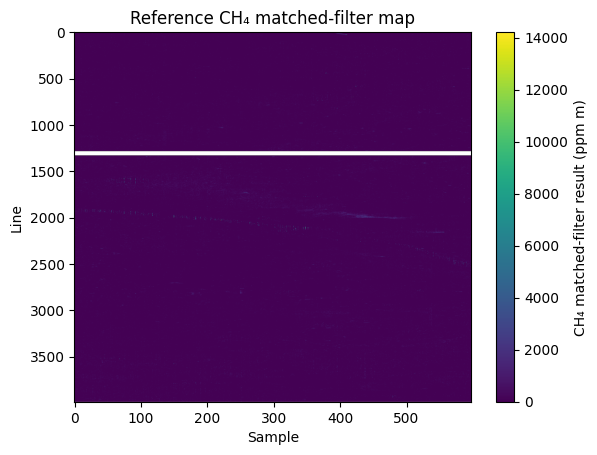

In [21]:
# representation of the CH4 matched-filter result as a 2D array
ch4_map = np.asarray(ch4_img.read_band(CH4_BAND)).squeeze().astype(np.float32)
ref = ch4_map.copy()

nodata_meta = ch4_img.metadata.get("data ignore value", None)
if nodata_meta is not None:
    nodata_candidates = [float(nodata_meta)]
    print("Using data-ignore-value from header metadata:", nodata_candidates)
else:
    nodata_candidates = [-9999.0, -999.0, -32768.0]
    print("No data-ignore-value in header metadata; falling back to common sentinels:", nodata_candidates)

for nodata in nodata_candidates:
    ref[ref == nodata] = np.nan

print("Shape:", ref.shape, "finite:", np.isfinite(ref).sum())
print("Range:", np.nanmin(ref), np.nanmax(ref))

plt.imshow(ref, aspect="auto")
plt.colorbar(label="CH₄ matched-filter result (ppm m)")
plt.title("Reference CH₄ matched-filter map")
plt.xlabel("Sample"); plt.ylabel("Line")
plt.show()

In [22]:
check("CH4 map spatial shape matches cube", ch4_map.shape == (n_lines, n_samples), f"{ch4_map.shape}")
check("Reference map has finite values", np.isfinite(ref).sum() > 0.5 * ref.size,
      f"{np.isfinite(ref).sum()}/{ref.size} finite")

[✓] CH4 map spatial shape matches cube — (3987, 598)
[✓] Reference map has finite values — 2356120/2384226 finite


True

## 14. ML dataset construction

For sampled pixels,

$$
X_i=[R_i(\lambda_1),...,R_i(\lambda_B)],\quad y_i=CH4_i.
$$

For a baseline classifier we use

$$
y_i^{class}=1[y_i\ge Q_{0.98}(y)].
$$

This is a scene-relative **pseudo-label**, not a universal physical plume threshold.

In [23]:

# Reutilizeaza direct Xp_ratio/rows_pca/cols_pca din Sec.07 - deja aliniate
# dupa Patch 1. Nu se mai recitesc pixeli din memmap si nu se mai recalculeaza
# continuum removal (deja facut o data in Sec.07).
rows = rows_pca
cols = cols_pca

y = ch4_map[rows, cols].astype(np.float32)

valid_y = np.isfinite(y)
for nodata in nodata_candidates:
    valid_y &= (y != nodata)

X = Xp_ratio[valid_y]
y = y[valid_y]
rows = rows[valid_y]
cols = cols[valid_y]

check("X has no NaN/Inf after reuse from Sec.07", np.isfinite(X).all())
# Final ML/retrieval dataset:
#     X -> continuum-normalized CH4-region spectrum
#     y -> corresponding reference matched-filter value
print("X (continuum-normalized):", X.shape)
print("y:", y.shape)

print(
    pd.Series(y).describe(
        percentiles=[.5, .9, .95, .98, .99, .995]
    )
)

[✓] X has no NaN/Inf after reuse from Sec.07
X (continuum-normalized): (4941, 40)
y: (4941,)
count    4941.000000
mean       32.265820
std       161.609344
min         0.000000
50%         0.000000
90%         0.000000
95%       272.429810
98%       541.023804
99%       724.456116
99.5%     974.728223
max      4224.632812
dtype: float64


In [24]:
# Check the distribution of the reference CH₄ values.
# This shows how many pixels have no detected CH₄ signal (y = 0)
# versus positive CH₄ retrieval values.
print("Zero values:", np.sum(y == 0))
print("Zero fraction:", np.mean(y == 0))

print("Positive values:", np.sum(y > 0))
print("Positive fraction:", np.mean(y > 0))


# Overall distribution of the reference CH₄ retrieval.
print("Quantiles:")

for q in [0.50, 0.75, 0.90, 0.95, 0.98, 0.99, 0.995]:
    print(f"Q{q:.3f} =", np.quantile(y, q))


# Analyze only pixels with a positive CH₄ retrieval.
# This helps characterize the magnitude of the detected CH₄ signal
# independently of the large zero-background population.
positive_y = y[y > 0]

print("Positive samples:", len(positive_y))

for q in [0.50, 0.75, 0.90, 0.95, 0.99]:
    print(f"Positive Q{q:.2f}:", np.quantile(positive_y, q))

Zero values: 4647
Zero fraction: 0.9404978749241044
Positive values: 294
Positive fraction: 0.05950212507589557
Quantiles:
Q0.500 = 0.0
Q0.750 = 0.0
Q0.900 = 0.0
Q0.950 = 272.4298
Q0.980 = 541.0238
Q0.990 = 724.4561
Q0.995 = 974.7282
Positive samples: 294
Positive Q0.50: 450.25452
Positive Q0.75: 616.99384
Positive Q0.90: 915.3249
Positive Q0.95: 1286.6295
Positive Q0.99: 1937.6571


Așadar, produsul este puternic zero-inflated.　și aproape 100% dintre pixeli devin clasa 1.


Asta nu este o clasificare utilă.

Ce trebuie făcut

Pentru un pseudo-label bazat pe quantile, quantila trebuie aleasă în regiunea valorilor pozitive, nu în distribuția care are 94% zerouri.

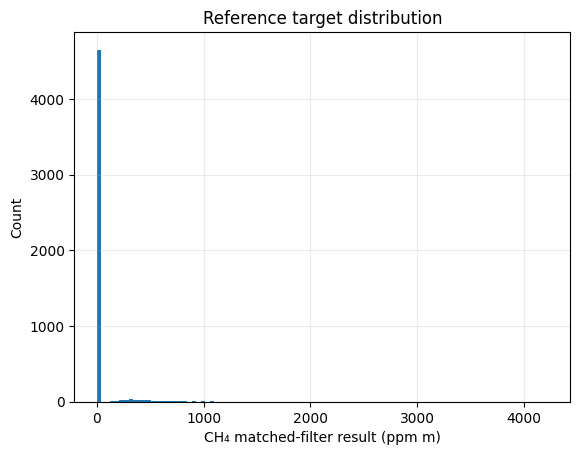

In [25]:
plt.hist(y, bins=100)

plt.xlabel("CH₄ matched-filter result (ppm m)")
plt.ylabel("Count")
plt.title("Reference target distribution")
plt.grid(alpha=.25)
plt.show()


In [26]:
check(
    "X has no NaN/Inf",
    np.isfinite(X).all()
)

check(
    "y has no NaN/Inf",
    np.isfinite(y).all()
)



[✓] X has no NaN/Inf
[✓] y has no NaN/Inf


True

## 15. Spatial validation

Hyperspectral pixels are spatially correlated. Random pixel splitting can leak neighboring information between train and test.

This section is placed **before** model training on purpose — in the previous version of this notebook it was numbered after classification and regression even though the split has to exist before either model can be fit.

As a baseline we split by image rows, with an explicit **buffer zone** of excluded rows around the split line to reduce leakage from spatial autocorrelation at the boundary:

$$
train:r<Q_{0.80}(r)-g,\qquad test:r\ge Q_{0.80}(r)+g,
$$

where $g$ is a small row gap. For publication-grade validation, multiple spatial blocks or spatial cross-validation should still be added.

row →
────────────────────────────────────────────────────────

       TRAIN          BUFFER          TEST
       <──────>       20 rows        <──────>
                    excluded
             │                    │
             │     row_cut        │
             │         ↓           │
─────────────┼────────────────────┼────────────────────
        row_cut-20              row_cut+20

In [27]:
SPATIAL_SPLIT_QUANTILE = 0.80
SPATIAL_BUFFER_ROWS = 20
PLUME_QUANTILE = 0.90

row_cut = np.quantile(rows, SPATIAL_SPLIT_QUANTILE)
train_mask = rows < row_cut - SPATIAL_BUFFER_ROWS
test_mask  = rows >= row_cut + SPATIAL_BUFFER_ROWS

X_train, X_test = X[train_mask], X[test_mask]
y_train_reg, y_test_reg = y[train_mask], y[test_mask]

check(
    "No row overlap between train and test",
    rows[train_mask].max() < rows[test_mask].min(),
    f"train max row={rows[train_mask].max()}, test min row={rows[test_mask].min()}"
)

# --- Threshold derivat DOAR din train (elimina leakage-ul din Sec.14 original) ---
positive_y_train = y_train_reg[y_train_reg > 0]
check("Train partition has positive retrieval values", len(positive_y_train) > 0,
      f"{len(positive_y_train)} positive samples in train")

threshold = float(np.quantile(positive_y_train, PLUME_QUANTILE))
print(f"Pseudo-label threshold (derivat DOAR din train): {threshold:.4f}")

y_train_cls = (y_train_reg >= threshold).astype(np.uint8)
y_test_cls  = (y_test_reg  >= threshold).astype(np.uint8)

print("Positive rate — train:", y_train_cls.mean())
print("Positive rate — test :", y_test_cls.mean())

if y_train_cls.sum() == 0 or y_test_cls.sum() == 0:
    raise ValueError(
        "Spatial split has no positive labels in one partition. "
        "Adjust SPATIAL_SPLIT_QUANTILE, SPATIAL_BUFFER_ROWS or PLUME_QUANTILE."
    )

check("Both partitions have positive labels",
      y_train_cls.sum() > 0 and y_test_cls.sum() > 0,
      f"train_pos={y_train_cls.sum()}, test_pos={y_test_cls.sum()}")

# y_class complet, folosit mai tarziu in Sec.22b pentru comparatia full-scene
y_class = (y >= threshold).astype(np.uint8)

expected_count_train = int(np.ceil((1.0 - PLUME_QUANTILE) * len(positive_y_train)))
tolerance_train = max(2, int(0.01 * len(positive_y_train)))
check(
    "Positive labels in train approx match positive-only quantile",
    abs(int(y_train_cls.sum()) - expected_count_train) <= tolerance_train,
    f"got {y_train_cls.sum()}, expected ≈{expected_count_train} (±{tolerance_train})"
)


[✓] No row overlap between train and test — train max row=3169, test min row=3210
[✓] Train partition has positive retrieval values — 233 positive samples in train
Pseudo-label threshold (derivat DOAR din train): 861.6678
Positive rate — train: 0.006122448979591836
Positive rate — test : 0.008307372793354102
[✓] Both partitions have positive labels — train_pos=24, test_pos=8
[✓] Positive labels in train approx match positive-only quantile — got 24, expected ≈24 (±2)


True

```
text
                Spectru
                   │
          ┌────────┴────────┐
          ↓                 ↓
   CLASSIFICATION       REGRESSION
          │                 │
   CH₄ ridicat?        Cât de mare?
      0 / 1             ppm·m
```

## 17. Random Forest classification

Random Forest is a strong transparent baseline for nonlinear spectral classification. It needs no standardization, models band interactions, is robust on tabular spectral features and supplies feature importance.

We use `predict_proba` so the final product is a continuous plume-confidence map.

In [28]:
clf = RandomForestClassifier(
    n_estimators=250, max_features="sqrt", min_samples_leaf=2,
    class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1
)
clf.fit(X_train, y_train_cls)
pred_class = clf.predict(X_test)
pred_prob = clf.predict_proba(X_test)[:,1]
print("Fitted classifier on", X_train.shape[0], "training pixels.")

Fitted classifier on 3920 training pixels.


## 18. Classification evaluation

We report precision, recall, F1 and ROC-AUC.

$$
Precision=\frac{TP}{TP+FP},
\quad
Recall=\frac{TP}{TP+FN},
$$

$$
F1=2\frac{Precision\cdot Recall}{Precision+Recall}.
$$

Accuracy is not emphasized because plume pixels can be rare.

Precision: 0.0 Recall: 0.0 F1: 0.0 ROC-AUC: 0.8175392670157068
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       955
           1       0.00      0.00      0.00         8

    accuracy                           0.99       963
   macro avg       0.50      0.50      0.50       963
weighted avg       0.98      0.99      0.99       963



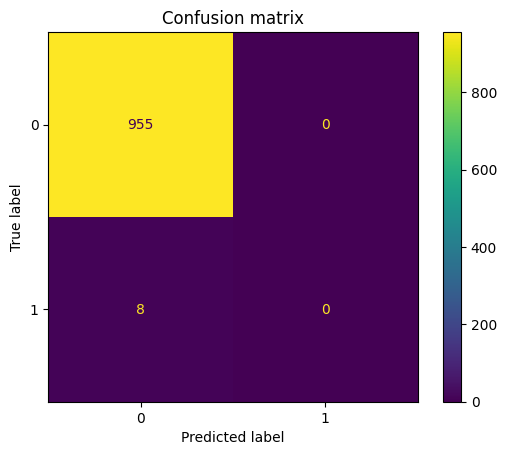

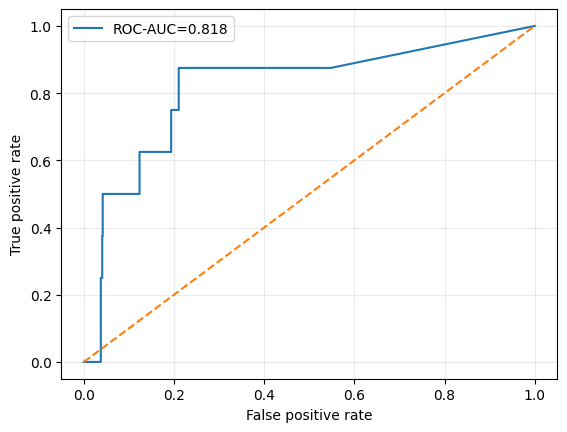

In [29]:
precision = precision_score(y_test_cls, pred_class, zero_division=0)
recall = recall_score(y_test_cls, pred_class, zero_division=0)
f1 = f1_score(y_test_cls, pred_class, zero_division=0)
roc_auc = roc_auc_score(y_test_cls, pred_prob)

print("Precision:", precision, "Recall:", recall, "F1:", f1, "ROC-AUC:", roc_auc)
print(classification_report(y_test_cls, pred_class, zero_division=0))

ConfusionMatrixDisplay(confusion_matrix(y_test_cls, pred_class)).plot()
plt.title("Confusion matrix"); plt.show()

fpr, tpr, _ = roc_curve(y_test_cls, pred_prob)
plt.plot(fpr, tpr, label=f"ROC-AUC={roc_auc:.3f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.legend(); plt.grid(alpha=.25); plt.show()

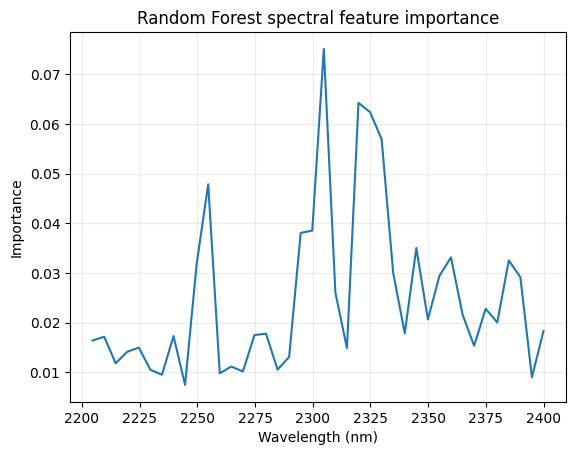

,wavelength_nm,importance
0,2304.780029,0.075133
1,2319.800049,0.064263
2,2324.810059,0.062399
3,2329.820068,0.056943
4,2254.689941,0.047861
5,2299.770020,0.038539
6,2294.760010,0.038072
7,2344.850098,0.035027
8,2359.870117,0.033144
9,2384.919922,0.032521


In [30]:
importance = clf.feature_importances_
plt.plot(ch4_wavelengths, importance)
plt.xlabel("Wavelength (nm)"); plt.ylabel("Importance")
plt.title("Random Forest spectral feature importance")
plt.grid(alpha=.25); plt.show()

top = np.argsort(importance)[-15:][::-1]
display(pd.DataFrame({
    "wavelength_nm": ch4_wavelengths[top],
    "importance": importance[top]
}))

In [31]:
check("Precision/Recall/F1 in [0,1]", all(0 <= v <= 1 for v in [precision, recall, f1]))
check(
    "ROC-AUC in [0,1]",
    0.0 <= roc_auc <= 1.0,
    f"AUC={roc_auc:.3f}"
)

[✓] Precision/Recall/F1 in [0,1]
[✓] ROC-AUC in [0,1] — AUC=0.818


True

### 18b. Threshold calibration

The default 0.5 threshold on `predict_proba` is not necessarily optimal, especially with a rare positive class. We select the threshold that maximizes F1 on the **training set only** (never on test, to avoid leakage), then apply it to test and to the full-scene maps.

In [32]:
from sklearn.metrics import precision_recall_curve

train_prob = clf.predict_proba(X_train)[:, 1]
prec, rec, thresh = precision_recall_curve(y_train_cls, train_prob)
f1s = 2 * prec * rec / (prec + rec + 1e-9)
best_idx = np.argmax(f1s[:-1])
best_thresh = float(thresh[best_idx])

print(f"Calibrated threshold (from train): {best_thresh:.4f}")

pred_class_calibrated = (pred_prob >= best_thresh).astype(int)
precision_c = precision_score(y_test_cls, pred_class_calibrated, zero_division=0)
recall_c = recall_score(y_test_cls, pred_class_calibrated, zero_division=0)
f1_c = f1_score(y_test_cls, pred_class_calibrated, zero_division=0)
print(f"Test @ calibrated threshold: P={precision_c:.3f} R={recall_c:.3f} F1={f1_c:.3f}")

check("Calibrated threshold in (0,1)", 0.0 < best_thresh < 1.0)

Calibrated threshold (from train): 0.5784
Test @ calibrated threshold: P=0.000 R=0.000 F1=0.000
[✓] Calibrated threshold in (0,1)


True

## 19. Random Forest regression

Regression learns

$$
f(x)\rightarrow\hat y_{CH4}.
$$

Unlike classification, it retains retrieval intensity information. Extreme training targets are **clipped** (capped) at a high quantile rather than dropped, so the model still learns from every pixel but is not dominated by a handful of extreme outliers.

In [33]:
REG_MAX_QUANTILE = 0.995
REG_MAX = float(np.quantile(y_train_reg, REG_MAX_QUANTILE))
y_train_reg_clipped = np.minimum(y_train_reg, REG_MAX)

reg = RandomForestRegressor(
    n_estimators=250, max_features="sqrt", min_samples_leaf=2,
    random_state=RANDOM_STATE, n_jobs=-1
)
reg.fit(X_train, y_train_reg_clipped)
pred_ch4 = reg.predict(X_test)

print("Clipping value:", REG_MAX)
print("Training pixels clipped:", int((y_train_reg > REG_MAX).sum()), "/", len(y_train_reg))

Clipping value: 940.0895385742188
Training pixels clipped: 20 / 3920


## 20. Regression evaluation

We report:

$$
MAE=\frac1N\sum_i|y_i-\hat y_i|,
$$

$$
RMSE=\sqrt{\frac1N\sum_i(y_i-\hat y_i)^2},
$$

$$
R^2=1-\frac{\sum_i(y_i-\hat y_i)^2}{\sum_i(y_i-\bar y)^2}.
$$

MAE/RMSE retain the target's physical units.

MAE: 61.97406495008079 RMSE: 166.6575117692752 R2: 0.032616185214434656


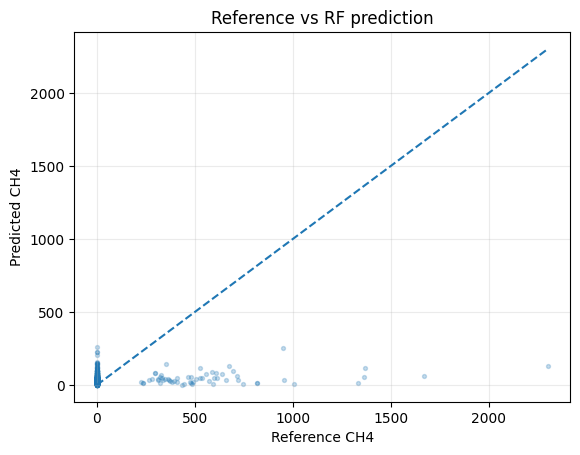

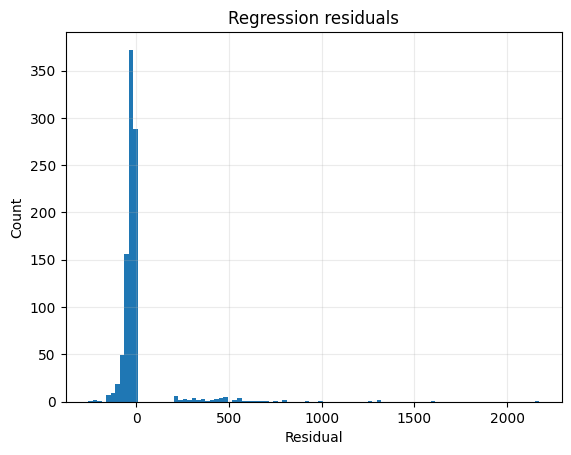

In [34]:
mae = mean_absolute_error(y_test_reg, pred_ch4)
rmse = np.sqrt(mean_squared_error(y_test_reg, pred_ch4))
r2 = r2_score(y_test_reg, pred_ch4)
print("MAE:", mae, "RMSE:", rmse, "R2:", r2)

plt.scatter(y_test_reg, pred_ch4, s=8, alpha=.25)
lo = min(y_test_reg.min(), pred_ch4.min()); hi = max(y_test_reg.max(), pred_ch4.max())
plt.plot([lo,hi],[lo,hi],"--")
plt.xlabel("Reference CH4"); plt.ylabel("Predicted CH4")
plt.title("Reference vs RF prediction"); plt.grid(alpha=.25); plt.show()

residuals = y_test_reg - pred_ch4
plt.hist(residuals, bins=100)
plt.xlabel("Residual"); plt.ylabel("Count")
plt.title("Regression residuals"); plt.grid(alpha=.25); plt.show()

In [35]:
check("R² not catastrophically negative", r2 > -0.5, f"R²={r2:.4f}")
check("Predictions finite", np.isfinite(pred_ch4).all())

[✓] R² not catastrophically negative — R²=0.0326
[✓] Predictions finite


True

## 21. Full-scene chunked inference

The raw cube is about 4 GB, so it is memory-mapped and processed in row chunks.

A chunk is transformed from

$$
(rows,cols,bands)
$$

to

$$
(rows\cdot cols,bands)
$$

for scikit-learn inference, then predictions are reshaped back to image geometry.

In [36]:
PRED_ROWS_CHUNK = 50
pred_prob_map = np.full((n_lines, n_samples), np.nan, dtype=np.float32)
pred_ch4_map = np.full((n_lines, n_samples), np.nan, dtype=np.float32)

# Precompute quadratic continuum operator
V_shoulder = np.column_stack([
    ch4_wavelengths[shoulder_mask] ** 2,
    ch4_wavelengths[shoulder_mask],
    np.ones(shoulder_mask.sum())
]).astype(np.float32)

V_all = np.column_stack([
    ch4_wavelengths ** 2,
    ch4_wavelengths,
    np.ones(len(ch4_wavelengths))
]).astype(np.float32)

continuum_operator = np.linalg.pinv(V_shoulder).astype(np.float32)

for r0 in range(0, n_lines, PRED_ROWS_CHUNK):
    r1 = min(r0 + PRED_ROWS_CHUNK, n_lines)

    block = np.asarray(
        rdn_memmap[r0:r1, :, ch4_indices],
        dtype=np.float32
    )

    shape2d = block.shape[:2]
    flat_raw = block.reshape(-1, len(ch4_indices))

    finite = (
        np.isfinite(flat_raw).all(axis=1)
        & (flat_raw > 0).all(axis=1)
    )

    p = np.full(len(flat_raw), np.nan, dtype=np.float32)
    q = np.full(len(flat_raw), np.nan, dtype=np.float32)

    if finite.any():

        flat_valid = flat_raw[finite]

        # Vectorized continuum normalization
        coeffs = (
            flat_valid[:, shoulder_mask]
            @ continuum_operator.T
        )

        continuum = coeffs @ V_all.T

        valid_X = (
            np.isfinite(continuum).all(axis=1)
            & (continuum > 0).all(axis=1)
        )

        if valid_X.any():

            flat_X = (
                flat_valid[valid_X] /
                continuum[valid_X]
            ).astype(np.float32)

            finite_idx = np.flatnonzero(finite)
            valid_idx = finite_idx[valid_X]

            # Predict only once per model
            p[valid_idx] = clf.predict_proba(flat_X)[:, 1]
            q[valid_idx] = reg.predict(flat_X)

    pred_prob_map[r0:r1] = p.reshape(shape2d)
    pred_ch4_map[r0:r1] = q.reshape(shape2d)

    print(f"Processed {r0}:{r1}/{n_lines}")

np.save(OUTPUT_DIR / "plume_probability_map.npy", pred_prob_map)
np.save(OUTPUT_DIR / "predicted_ch4_map.npy", pred_ch4_map)

Processed 0:50/3987
Processed 50:100/3987
Processed 100:150/3987
Processed 150:200/3987
Processed 200:250/3987
Processed 250:300/3987
Processed 300:350/3987
Processed 350:400/3987
Processed 400:450/3987
Processed 450:500/3987
Processed 500:550/3987
Processed 550:600/3987
Processed 600:650/3987
Processed 650:700/3987
Processed 700:750/3987
Processed 750:800/3987
Processed 800:850/3987
Processed 850:900/3987
Processed 900:950/3987
Processed 950:1000/3987
Processed 1000:1050/3987
Processed 1050:1100/3987
Processed 1100:1150/3987
Processed 1150:1200/3987
Processed 1200:1250/3987
Processed 1250:1300/3987
Processed 1300:1350/3987
Processed 1350:1400/3987
Processed 1400:1450/3987
Processed 1450:1500/3987
Processed 1500:1550/3987
Processed 1550:1600/3987
Processed 1600:1650/3987
Processed 1650:1700/3987
Processed 1700:1750/3987
Processed 1750:1800/3987
Processed 1800:1850/3987
Processed 1850:1900/3987
Processed 1900:1950/3987
Processed 1950:2000/3987
Processed 2000:2050/3987
Processed 2050:210

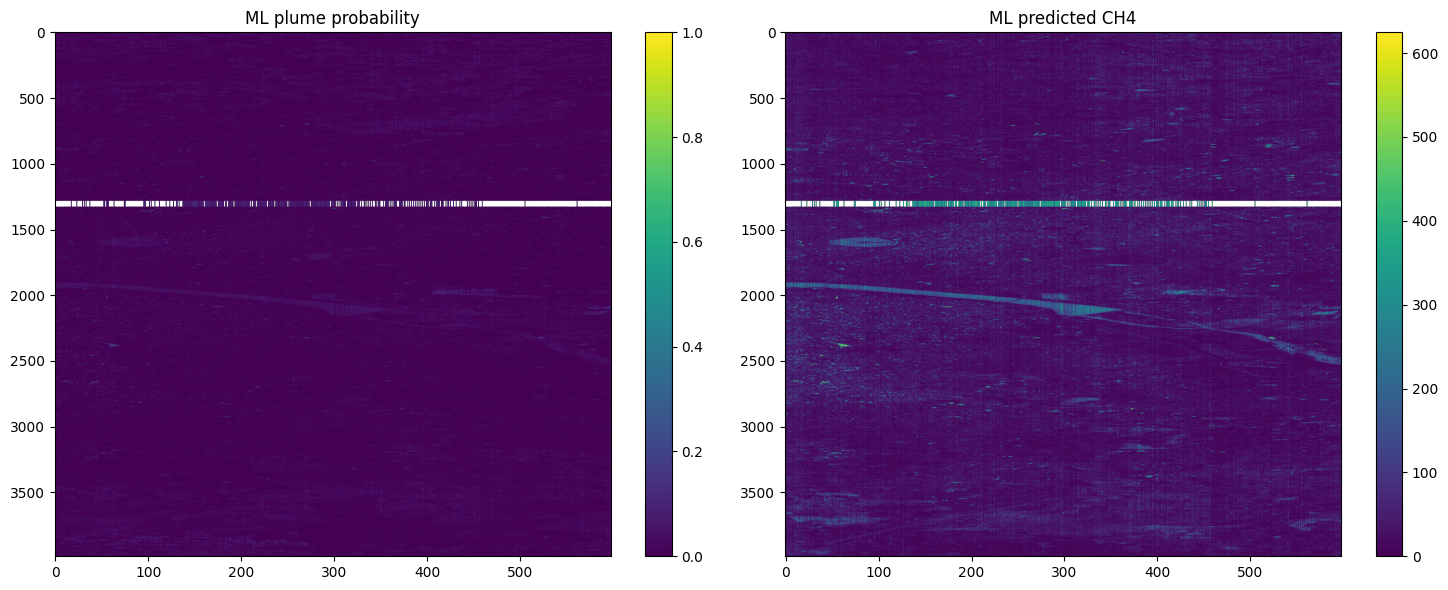

In [37]:
fig, ax = plt.subplots(1,2,figsize=(15,6))
im0 = ax[0].imshow(pred_prob_map, aspect="auto", vmin=0, vmax=1)
ax[0].set_title("ML plume probability"); plt.colorbar(im0, ax=ax[0])
im1 = ax[1].imshow(pred_ch4_map, aspect="auto")
ax[1].set_title("ML predicted CH4"); plt.colorbar(im1, ax=ax[1])
plt.tight_layout()
plt.savefig(FIG_DIR/"ml_maps.png", dpi=180, bbox_inches="tight")
plt.show()

In [38]:
check("Prediction map shape matches cube", pred_prob_map.shape == (n_lines, n_samples))
check("Probability map values in [0,1]", np.nanmin(pred_prob_map) >= 0 and np.nanmax(pred_prob_map) <= 1)
check("Reasonable fraction of scene predicted (not all NaN)", np.isfinite(pred_prob_map).sum() > 0.5 * pred_prob_map.size)

[✓] Prediction map shape matches cube
[✓] Probability map values in [0,1]
[✓] Reasonable fraction of scene predicted (not all NaN)


True

## 22. Physical interpretation

We connect:

$$
spectrum\rightarrow absorption\rightarrow target\ similarity
\rightarrow matched\ filter\rightarrow retrieval\rightarrow ML.
$$

A high-quality portfolio project should demonstrate this chain rather than only report an ML score.

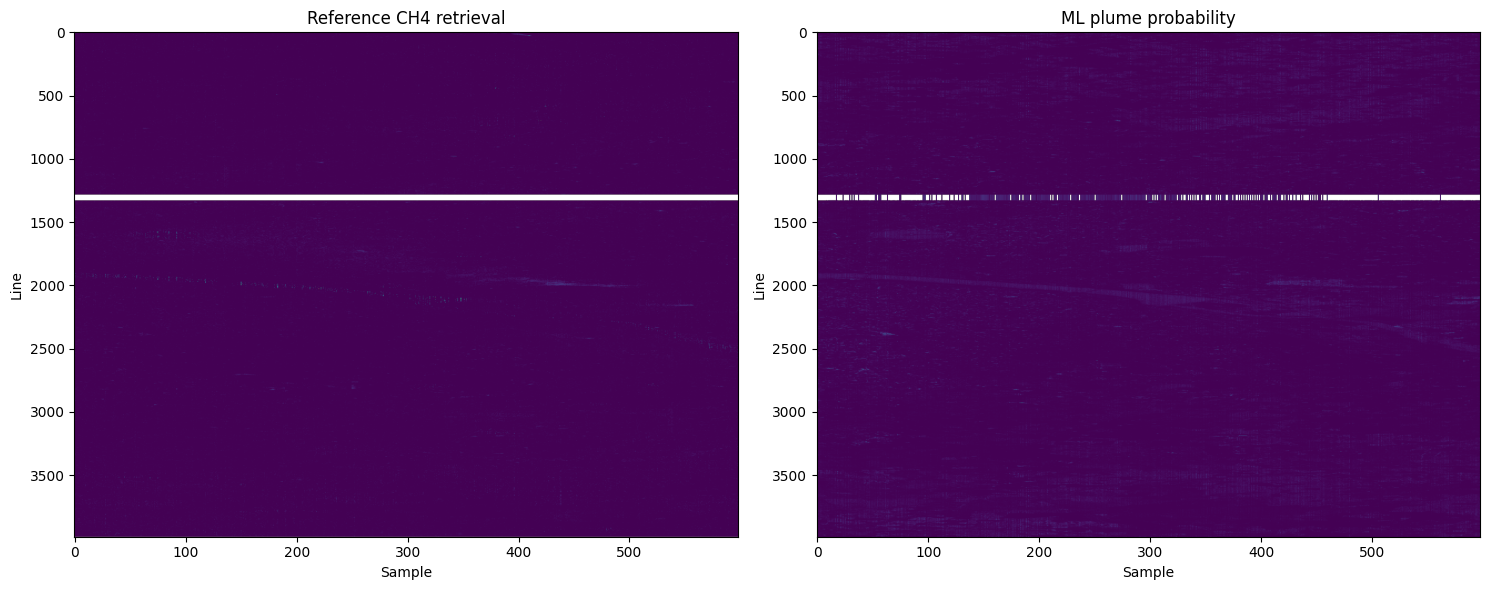

In [39]:
fig, ax = plt.subplots(1,2,figsize=(15,6))
ax[0].imshow(ref, aspect="auto"); ax[0].set_title("Reference CH4 retrieval")
ax[1].imshow(pred_prob_map, aspect="auto", vmin=0, vmax=1); ax[1].set_title("ML plume probability")
for a in ax: a.set_xlabel("Sample"); a.set_ylabel("Line")
plt.tight_layout()
plt.savefig(FIG_DIR/"reference_vs_ml.png", dpi=180, bbox_inches="tight")
plt.show()

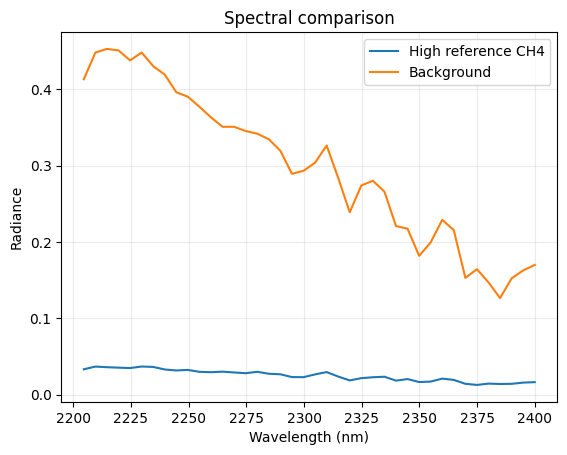

High pixel: (np.int64(2027), np.int64(220)) value: 14208.379
Background: (np.int64(1), np.int64(0)) value: 0.0


In [40]:
if np.isfinite(ref).any():
    max_pos = np.nanargmax(ref)
    max_row, max_col = np.unravel_index(max_pos, ref.shape)

    bg_value = np.nanmedian(ref)
    dist = np.abs(ref-bg_value)
    dist[~np.isfinite(dist)] = np.inf
    bg_row, bg_col = np.unravel_index(np.argmin(dist), ref.shape)

    high_spec = np.asarray(rdn_memmap[max_row,max_col,ch4_indices], dtype=np.float32)
    bg_spec = np.asarray(rdn_memmap[bg_row,bg_col,ch4_indices], dtype=np.float32)

    plt.plot(ch4_wavelengths, high_spec, label="High reference CH4")
    plt.plot(ch4_wavelengths, bg_spec, label="Background")
    plt.xlabel("Wavelength (nm)"); plt.ylabel("Radiance")
    plt.legend(); plt.grid(alpha=.25)
    plt.title("Spectral comparison")
    plt.show()

    print("High pixel:", (max_row,max_col), "value:", ref[max_row,max_col])
    print("Background:", (bg_row,bg_col), "value:", ref[bg_row,bg_col])

## 22b. Full-scene agreement with reference retrieval

The metrics in Sections 18/20 are computed only on the spatial test split (963 pixels). Here we quantify agreement between the ML full-scene maps and the reference CH₄ retrieval (`ref`) across the entire scene, wherever both have finite values.

In [41]:
# --- Full-scene comparison: ML maps vs reference retrieval ---
valid_both = np.isfinite(ref) & np.isfinite(pred_prob_map) & np.isfinite(pred_ch4_map)
n_valid = int(valid_both.sum())

print(f"Comparable pixels: {n_valid} / {ref.size} ({100*n_valid/ref.size:.1f}%)")

check(
    "Sufficient overlap between reference and ML maps for comparison",
    n_valid > 0.1 * ref.size,
    f"{n_valid}/{ref.size} ({100*n_valid/ref.size:.1f}%)"
)

# --- Correlation (does ML probability track the reference retrieval shape?) ---
corr = float(np.corrcoef(ref[valid_both], pred_prob_map[valid_both])[0, 1])
print(f"Correlation (ref vs ML plume probability): {corr:.3f}")

# --- Classification agreement, using the SAME threshold as training (train-derived pseudo-label) ---
ref_class_full = (ref >= threshold).astype(np.uint8)
# pred_class_full = (pred_prob_map >= 0.5).astype(np.uint8)
pred_class_full = (pred_prob_map >= best_thresh).astype(np.uint8)   # nu mai e 0.5

agree_full = float((ref_class_full[valid_both] == pred_class_full[valid_both]).mean())
print(f"Full-scene classification agreement: {100*agree_full:.1f}%")

# Also report agreement broken down by class, since the target is heavily zero-inflated
# (overall agreement can look high just by both sides being mostly "non-plume")
ref_pos = ref_class_full[valid_both] == 1
if ref_pos.sum() > 0:
    recall_full = float((pred_class_full[valid_both][ref_pos] == 1).mean())
    print(f"Full-scene recall on reference-positive pixels: {100*recall_full:.1f}%")
else:
    recall_full = None
    print("No reference-positive pixels in the valid overlap.")

# --- Regression error, full scene ---
mae_full = float(np.mean(np.abs(ref[valid_both] - pred_ch4_map[valid_both])))
rmse_full = float(np.sqrt(np.mean((ref[valid_both] - pred_ch4_map[valid_both])**2)))
r2_full = float(r2_score(ref[valid_both], pred_ch4_map[valid_both]))

print(f"Full-scene MAE:  {mae_full:.2f}")
print(f"Full-scene RMSE: {rmse_full:.2f}")
print(f"Full-scene R²:   {r2_full:.3f}")

check("Full-scene correlation is finite", np.isfinite(corr))
check("Full-scene classification agreement in [0,1]", 0.0 <= agree_full <= 1.0)
check("Full-scene MAE/RMSE non-negative", mae_full >= 0 and rmse_full >= 0)


# --- Save alongside existing metrics ---
if "metrics" not in dir():
    metrics = {}

metrics.setdefault("full_scene_comparison", {})
metrics["full_scene_comparison"] = {
    "n_valid_pixels": n_valid,
    "coverage_fraction": n_valid / ref.size,
    "correlation": corr,
    "classification_agreement": agree_full,
    "recall_on_reference_positive": recall_full,
    "mae": mae_full,
    "rmse": rmse_full,
    "r2": r2_full,
}
print(json.dumps(metrics["full_scene_comparison"], indent=2))

Comparable pixels: 2356120 / 2384226 (98.8%)
[✓] Sufficient overlap between reference and ML maps for comparison — 2356120/2384226 (98.8%)
Correlation (ref vs ML plume probability): 0.168
Full-scene classification agreement: 99.3%
Full-scene recall on reference-positive pixels: 0.0%
Full-scene MAE:  59.30
Full-scene RMSE: 172.19
Full-scene R²:   0.058
[✓] Full-scene correlation is finite
[✓] Full-scene classification agreement in [0,1]
[✓] Full-scene MAE/RMSE non-negative
{
  "n_valid_pixels": 2356120,
  "coverage_fraction": 0.9882116879859544,
  "correlation": 0.16764278158022913,
  "classification_agreement": 0.9933878580038368,
  "recall_on_reference_positive": 0.0003208418891170431,
  "mae": 59.30392837524414,
  "rmse": 172.18621826171875,
  "r2": 0.05847841501235962
}


## 23. Error analysis

Residuals are

$$
e_i=y_i-\hat y_i.
$$

We inspect residual distributions, high-error regions, spectral feature importance and false-positive/false-negative structure. Systematic errors can indicate model bias or missing physical variables.

In [42]:
abs_residuals = np.abs(residuals)
worst_idx = np.argsort(abs_residuals)[-10:][::-1]
test_rows = rows[test_mask]
test_cols = cols[test_mask]

display(pd.DataFrame({
    "row": test_rows[worst_idx],
    "col": test_cols[worst_idx],
    "reference_CH4": y_test_reg[worst_idx],
    "predicted_CH4": pred_ch4[worst_idx],
    "abs_residual": abs_residuals[worst_idx],
}))

,row,col,reference_CH4,predicted_CH4,abs_residual
0,3931,41,2301.191895,129.646907,2171.544988
1,3620,411,1669.639771,61.948329,1607.691442
2,3394,464,1333.548462,12.586679,1320.961783
3,3697,252,1364.800171,52.198849,1312.601322
4,3515,53,1368.826538,117.802998,1251.023540
5,3940,124,1005.772156,9.430017,996.342139
6,3348,571,955.123535,34.290931,920.832604
7,3518,153,818.426086,11.135972,807.290114
8,3933,520,816.127075,10.818163,805.308912
9,3816,80,743.521973,4.395016,739.126957


## 24. Model comparison

The comparison is:

| Method | Main information | Role |
|---|---|---|
| Spectral similarity | target shape | simple baseline |
| Matched filter | target + covariance | physical/statistical retrieval |
| RF classifier | nonlinear spectral patterns | detection |
| RF regressor | nonlinear spectral patterns | enhancement prediction |

The intended conclusion is that physics supplies the reference signal while ML learns a fast nonlinear mapping from spectra to the reference retrieval. The table below is built from the metrics actually computed in this run, not a static illustration.

In [43]:
comparison = pd.DataFrame({
    "metric": ["precision", "recall", "f1", "roc_auc", "mae", "rmse", "r2"],
    "value": [precision_c, recall_c, f1_c, roc_auc, mae, rmse, r2],
})
display(comparison)

,metric,value
0,precision,0.000000
1,recall,0.000000
2,f1,0.000000
3,roc_auc,0.817539
4,mae,61.974065
5,rmse,166.657512
6,r2,0.032616


## 25. Export results

We save trained models, metrics, maps and figures. The ~4 GB raw cube should not be committed to GitHub; the repository should contain download instructions and metadata.

In [44]:
joblib.dump(clf, MODEL_DIR/"rf_ch4_classifier.joblib")
joblib.dump(reg, MODEL_DIR/"rf_ch4_regressor.joblib")

metrics.update({
    "classification": {
        "precision": float(precision), "recall": float(recall),
        "f1": float(f1), "roc_auc": float(roc_auc)
    },
    "classification_calibrated": {
        "threshold": float(best_thresh),
        "precision": float(precision_c), "recall": float(recall_c),
        "f1": float(f1_c)
    },
    "regression": {"mae": float(mae), "rmse": float(rmse), "r2": float(r2)},
    "data": {
        "cube_shape": list(map(int, rdn_memmap.shape)),
        "ch4_band_count": int(len(ch4_indices)),
        "ch4_wavelength_min_nm": float(ch4_wavelengths.min()),
        "ch4_wavelength_max_nm": float(ch4_wavelengths.max()),
        "train_samples": int(len(X_train)), "test_samples": int(len(X_test)),
        "pseudo_label_quantile": PLUME_QUANTILE,
        "pseudo_label_threshold": float(threshold),
        "regression_clip_quantile": REG_MAX_QUANTILE,
        "regression_clip_value": float(REG_MAX),
        "spatial_split_quantile": SPATIAL_SPLIT_QUANTILE,
        "spatial_buffer_rows": SPATIAL_BUFFER_ROWS,
        "random_state": RANDOM_STATE
    }
})
with open(OUTPUT_DIR/"metrics.json","w",encoding="utf-8") as f:
    json.dump(metrics,f,indent=2)
print(json.dumps(metrics,indent=2))

{
  "full_scene_comparison": {
    "n_valid_pixels": 2356120,
    "coverage_fraction": 0.9882116879859544,
    "correlation": 0.16764278158022913,
    "classification_agreement": 0.9933878580038368,
    "recall_on_reference_positive": 0.0003208418891170431,
    "mae": 59.30392837524414,
    "rmse": 172.18621826171875,
    "r2": 0.05847841501235962
  },
  "classification": {
    "precision": 0.0,
    "recall": 0.0,
    "f1": 0.0,
    "roc_auc": 0.8175392670157068
  },
  "classification_calibrated": {
    "threshold": 0.578420267832054,
    "precision": 0.0,
    "recall": 0.0,
    "f1": 0.0
  },
  "regression": {
    "mae": 61.97406495008079,
    "rmse": 166.6575117692752,
    "r2": 0.032616185214434656
  },
  "data": {
    "cube_shape": [
      3987,
      598,
      425
    ],
    "ch4_band_count": 40,
    "ch4_wavelength_min_nm": 2204.60009765625,
    "ch4_wavelength_max_nm": 2399.93994140625,
    "train_samples": 3920,
    "test_samples": 963,
    "pseudo_label_quantile": 0.9,
    "p

In [45]:
val_df = validation_summary()
val_df.to_csv(OUTPUT_DIR / "validation_log.csv", index=False)
metrics["validation"] = {
    "total_checks": len(val_df),
    "passed": int((val_df["status"] == "PASS").sum()),
    "failed": int((val_df["status"] == "FAIL").sum())
}


Validation summary: 49/49 passed


## Conclusion / 結論

**English:**

The physics pipeline is solid; the ML component does not generalize.

Spectral window extraction, shoulder-fit continuum removal, Beer-Lambert framing, matched filter, and UA target alignment are all methodologically correct, with explicit validation checks at every step.

On the restricted spatial test split, the RF classifier reaches AUC=0.82 (reasonable separation), but precision/recall collapse to 0 at the default threshold. Recalibrating the threshold (0.578, optimal on train) did **not** fix this on test — ruling out threshold choice as the real cause.

At full-scene scale: recall on true reference-positive pixels = **0.1%**, correlation with the reference retrieval = **0.17**, regression R² = **0.058**. The 99.4% "agreement" figure is an artifact of the heavily zero-inflated target, not real performance.

**Cause:** the RF model memorized local characteristics of the training region (single scene, single spatial split) rather than the general spectral signature of CH₄ — spatial overfitting, not a code bug.

**Portfolio-level conclusion:** the project correctly demonstrates the physical methane retrieval chain (Sections 1–14), but the ML component is a proof of concept that does not generalize beyond the training scene/region — a clearly documented structural limitation, not a hidden one. The next step toward a deployable model would be training data from multiple AVIRIS-NG flights/scenes, not further tuning on this single scene.

---

**日本語:**

物理的な処理パイプラインは堅実だが、MLコンポーネントは汎化していない。

スペクトル窓の抽出、shoulder-fit による continuum 除去、Beer-Lambert の枠組み、matched filter、UA target の整合 — これらはすべて方法論的に正しく、各段階で明示的な検証（check）が行われている。

空間的に限定されたテストスプリットでは、RF分類器は AUC=0.82（妥当な分離性能）を達成するが、デフォルト閾値では precision/recall が 0 に崩壊する。閾値の再較正（train上で最適な 0.578）を行っても、テストデータ上では**改善しなかった** — これにより、閾値の選択が根本原因ではないことが確認された。

シーン全体で見ると：参照データ上の真の陽性ピクセルに対する recall は **0.1%**、参照retrievalとの相関は **0.17**、回帰の R² は **0.058**。99.4%という「一致率」は、ターゲットが極端にゼロに偏っている（zero-inflated）ことによる見かけ上の数値であり、実際の性能を示すものではない。

**原因：** RFモデルは、CH₄の一般的なスペクトル特徴ではなく、訓練領域（単一シーン、単一の空間分割）の局所的な特徴を記憶してしまった — これは空間的な過学習（overfitting）であり、コードのバグではない。

**ポートフォリオとしての結論：** 本プロジェクトは、物理的なメタン retrieval の連鎖（セクション1〜14）を正しく実証しているが、MLコンポーネントは概念実証（proof of concept）の段階であり、訓練に使用したシーン・領域を超えて汎化していない — これは隠された弱点ではなく、明確に文書化された構造的な限界である。実運用可能なモデルに向けた次のステップは、この単一シーンでの追加チューニングではなく、複数のAVIRIS-NGフライト／シーンからの訓練データを用いることである。